# Regression and classification on the video-search features

**Question.** Search ranks every second of a video with a hand-set formula: `α·picture + (1−α)·speech`.
Can small supervised models learn a better score from the same signals?

The pretrained encoders (CLIP, Whisper, MiniLM) stay frozen. Everything here trains on **features extracted from them**.

Run `python scripts/run_analysis.py` to regenerate every table and figure used below.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display
pd.set_option("display.width", 160)
T, F = Path("../results/ml"), Path("../results/ml/figures")
show = lambda name, w=900: display(Image(filename=str(F / name), width=w))
data = pd.read_csv(T / "dataset.csv.gz")
print(f"{len(data):,} rows = {data.query_id.nunique()} queries x seconds, {data.video_id.nunique()} videos, "
      f"{data.rel_binary.mean():.1%} of seconds are inside a true moment")

28,900 rows = 86 queries x seconds, 9 videos, 8.3% of seconds are inside a true moment


## 1. Data

* **Videos:** 9 public-domain NASA "This Week @NASA" episodes (about 45 minutes).
* **Benchmark:** 86 queries, each with the time interval of its true answer (`benchmark/queries.json`). Intervals come from the Whisper transcripts, so labels lean toward what is *said*.
* **One row = one (query, second).** Features come from the search pipeline: raw and normalised picture/speech similarity, z-scores and within-video ranks, ±2 s smoothed scores, frame-to-frame change, whether speech is present, position in the video, query length, and the hand-set fused score.
* **Targets.** Regression: graded relevance, 1 inside the true interval and `exp(−distance/5 s)` outside. Classification: is the second inside the true interval?

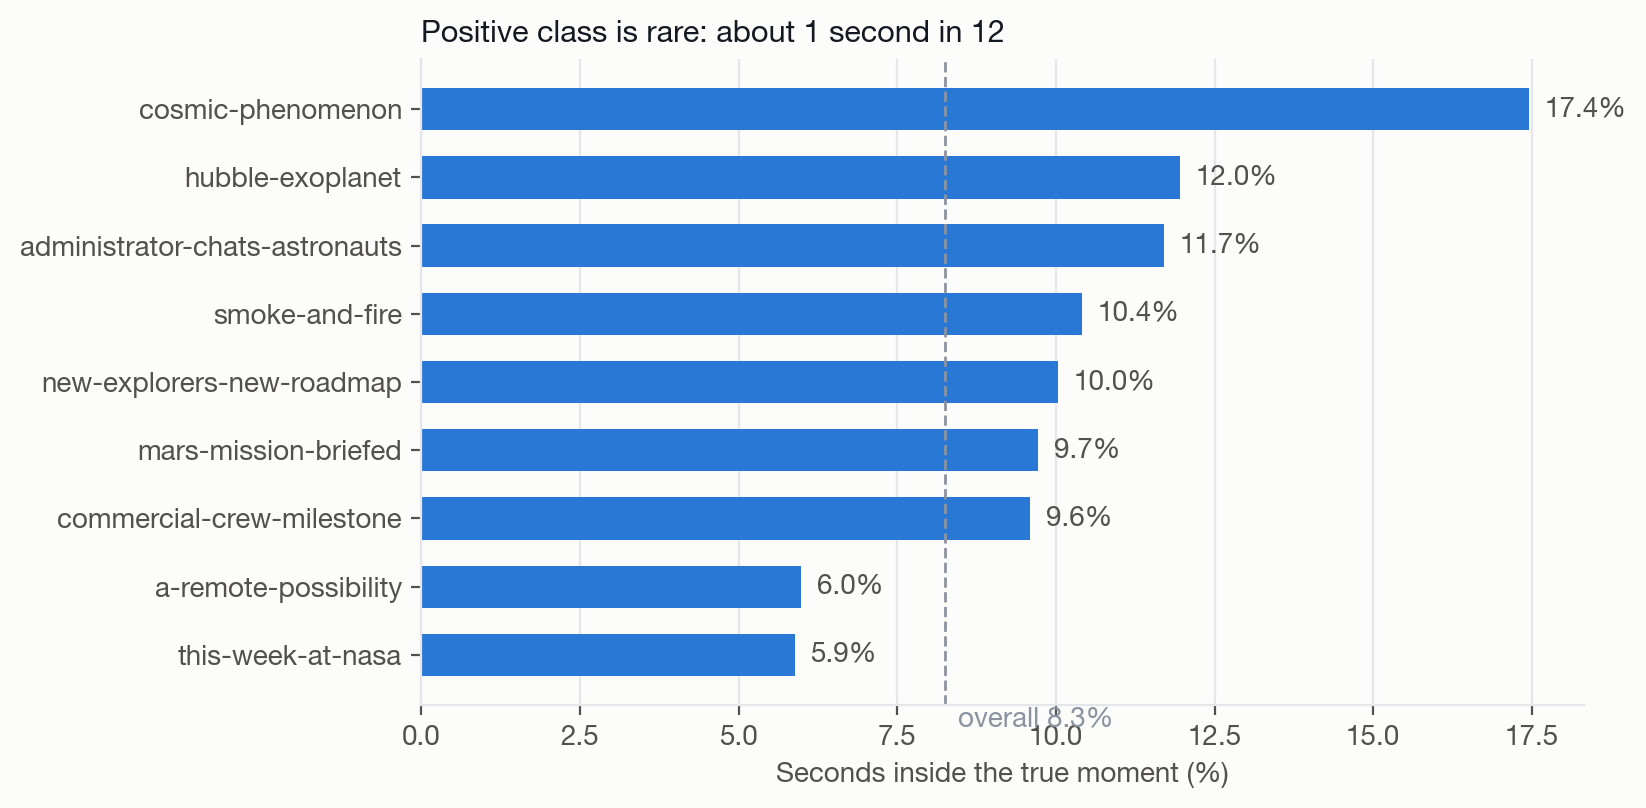

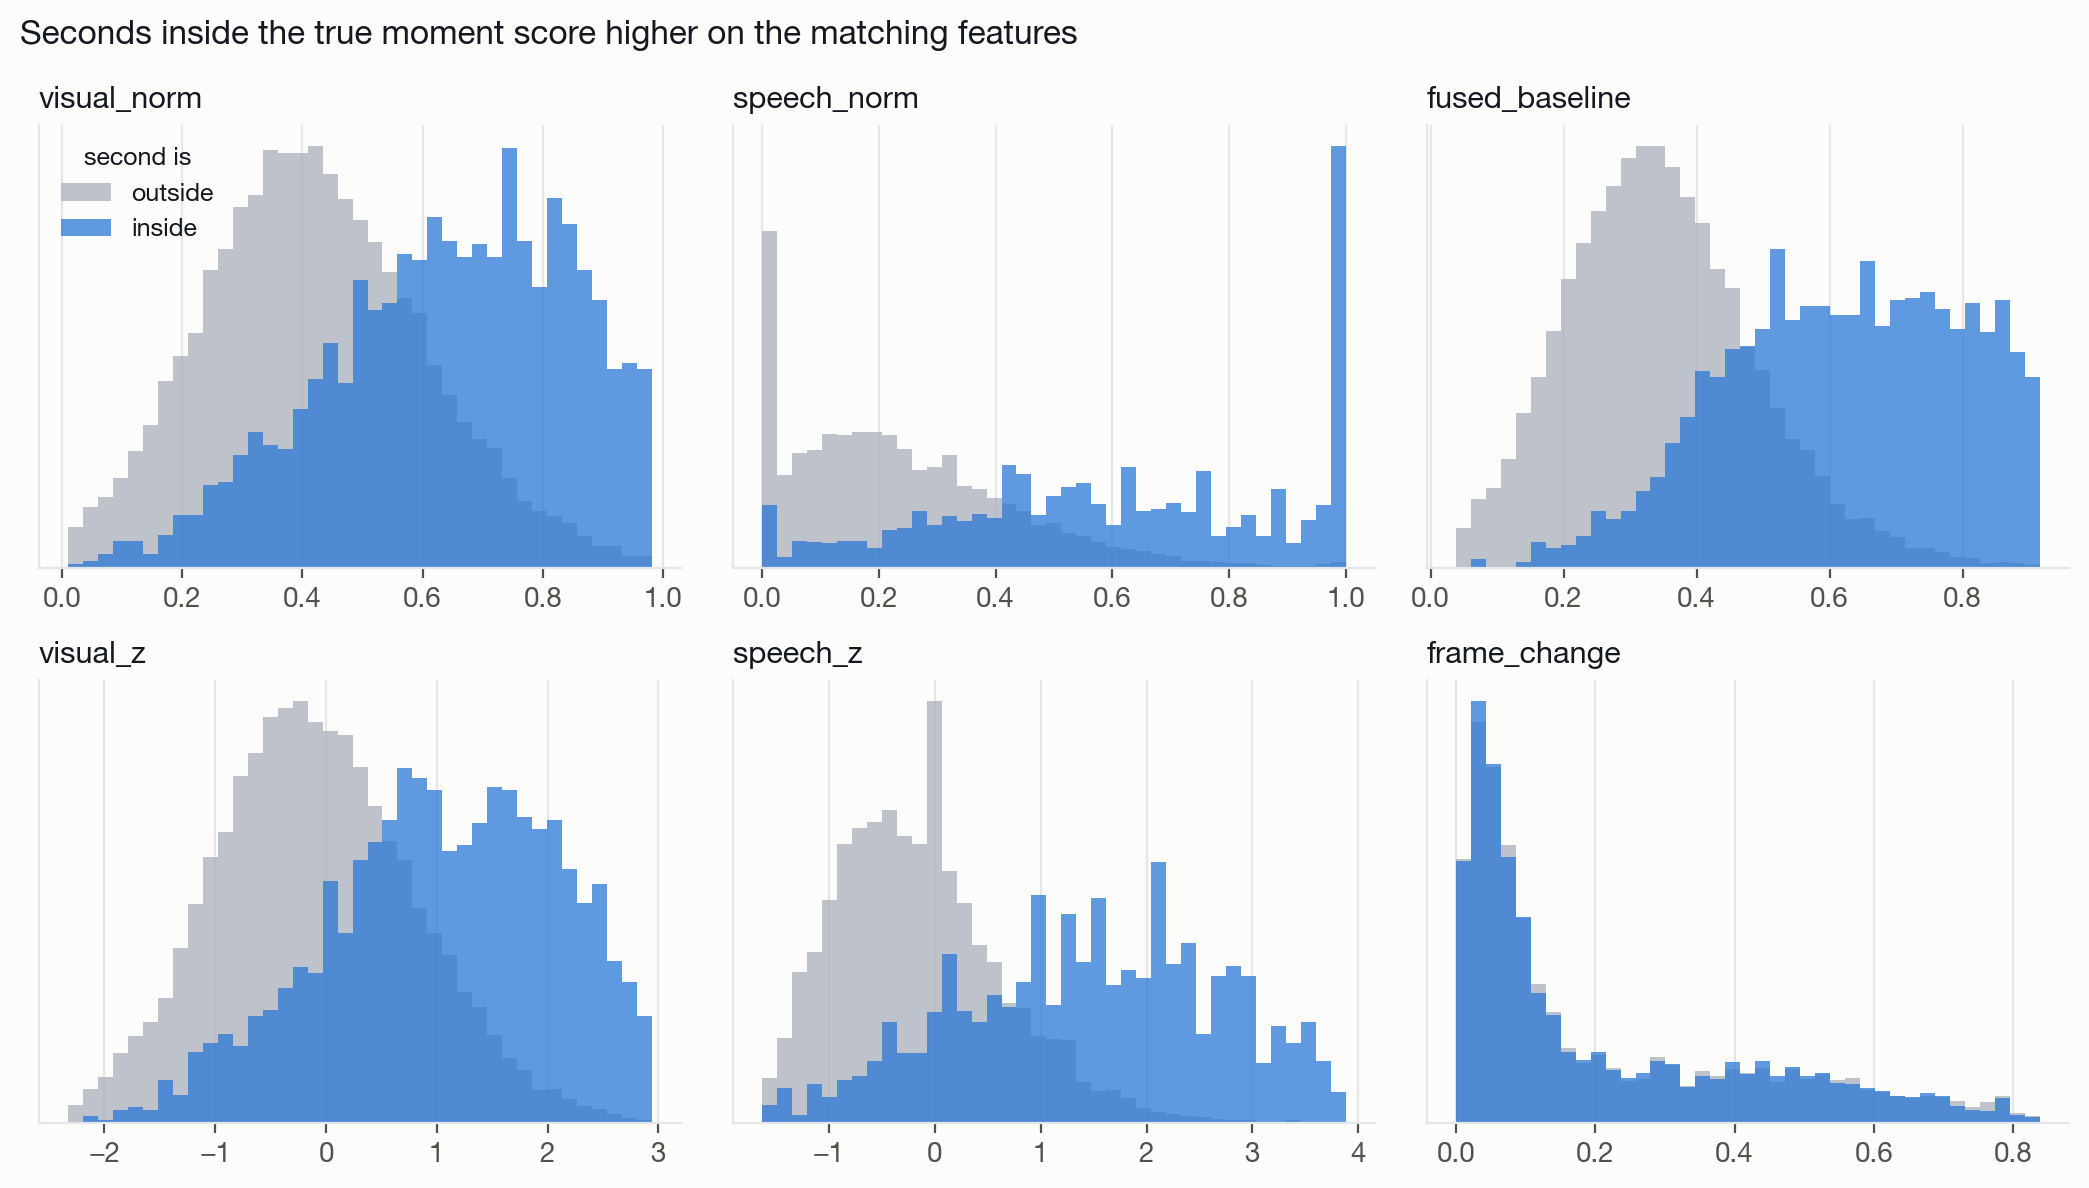

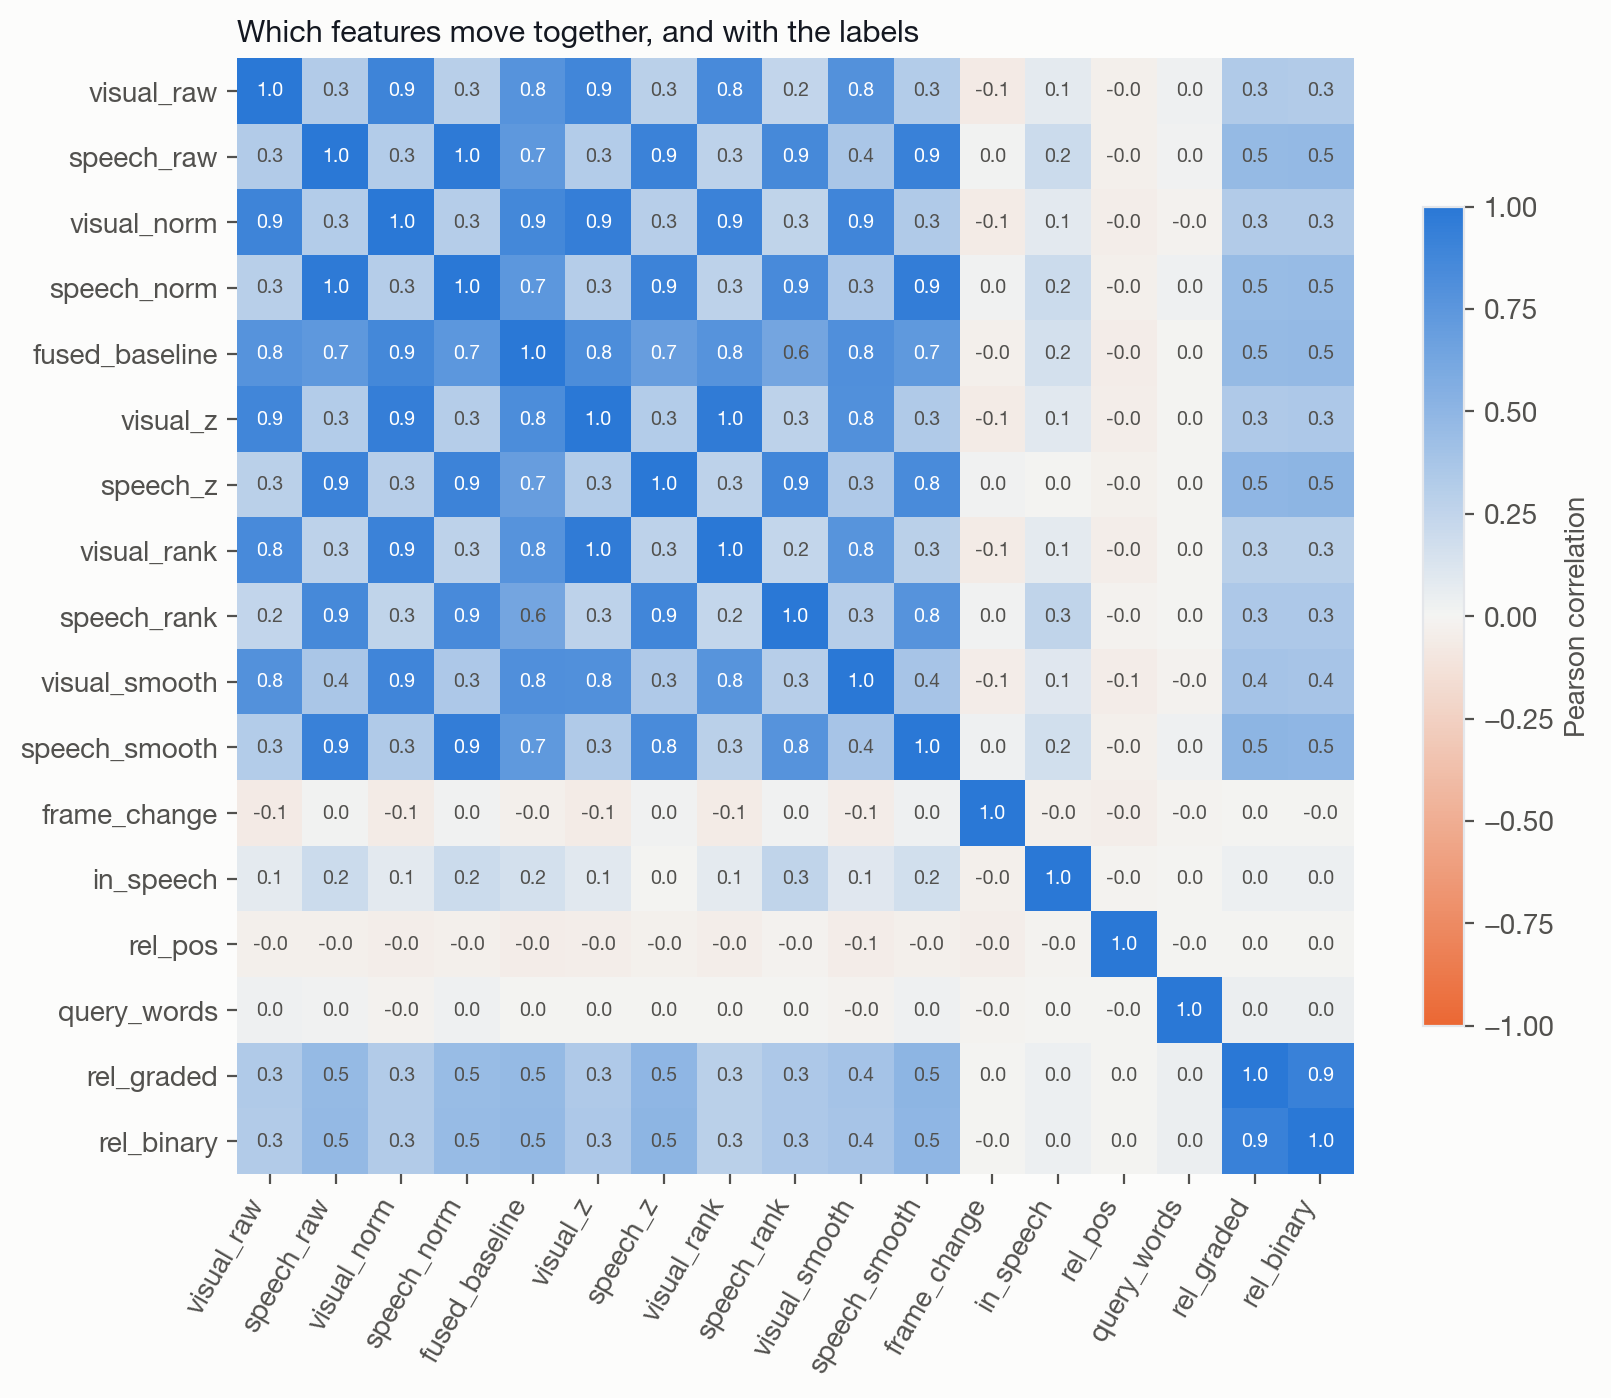

In [2]:
show("01_class_balance.png", 650); show("02_feature_distributions.png"); show("03_correlation_heatmap.png", 760)

## 2. Models and protocol

| Task | Models |
|---|---|
| Regression | Ridge, Random forest, Gradient boosting (+ mean baseline) |
| Classification | Logistic regression, k-nearest neighbours, Gradient boosting (+ prior baseline) |

* **Leave-one-video-out:** each video is predicted by models trained on the other eight, so nothing leaks between neighbouring seconds or queries.
* **Hyper-parameters** are grid-searched inside each training split (grouped 3-fold CV). The classification **threshold** maximises F1 on the training split only.
* Positives are rare (about 8%), so classifiers use class weights and are judged by precision, recall, F1 and PR-AUC, not accuracy.

In [3]:
pd.read_csv(T / "best_params.csv").groupby(["task", "model"]).params.agg(lambda s: s.value_counts().index[0])

task            model            
classification  gradient_boosting    {'model__learning_rate': 0.05, 'model__max_dep...
                knn                                        {'model__n_neighbors': 151}
                logistic                                            {'model__C': 10.0}
regression      gradient_boosting    {'model__learning_rate': 0.05, 'model__max_dep...
                random_forest        {'model__max_depth': 12, 'model__min_samples_l...
                ridge                                          {'model__alpha': 100.0}
Name: params, dtype: object

## 3. Regression

In [4]:
reg = pd.read_csv(T / "regression_summary.csv")
reg[["model", "rmse_mean", "rmse_std", "mae_mean", "r2_mean", "spearman_mean"]].round(3)

,model,rmse_mean,rmse_std,mae_mean,r2_mean,spearman_mean
0,dummy,0.319,0.045,0.204,-0.028,0.000
1,gradient_boosting,0.237,0.033,0.128,0.422,0.415
2,random_forest,0.240,0.035,0.130,0.409,0.371
3,ridge,0.245,0.034,0.153,0.390,0.398


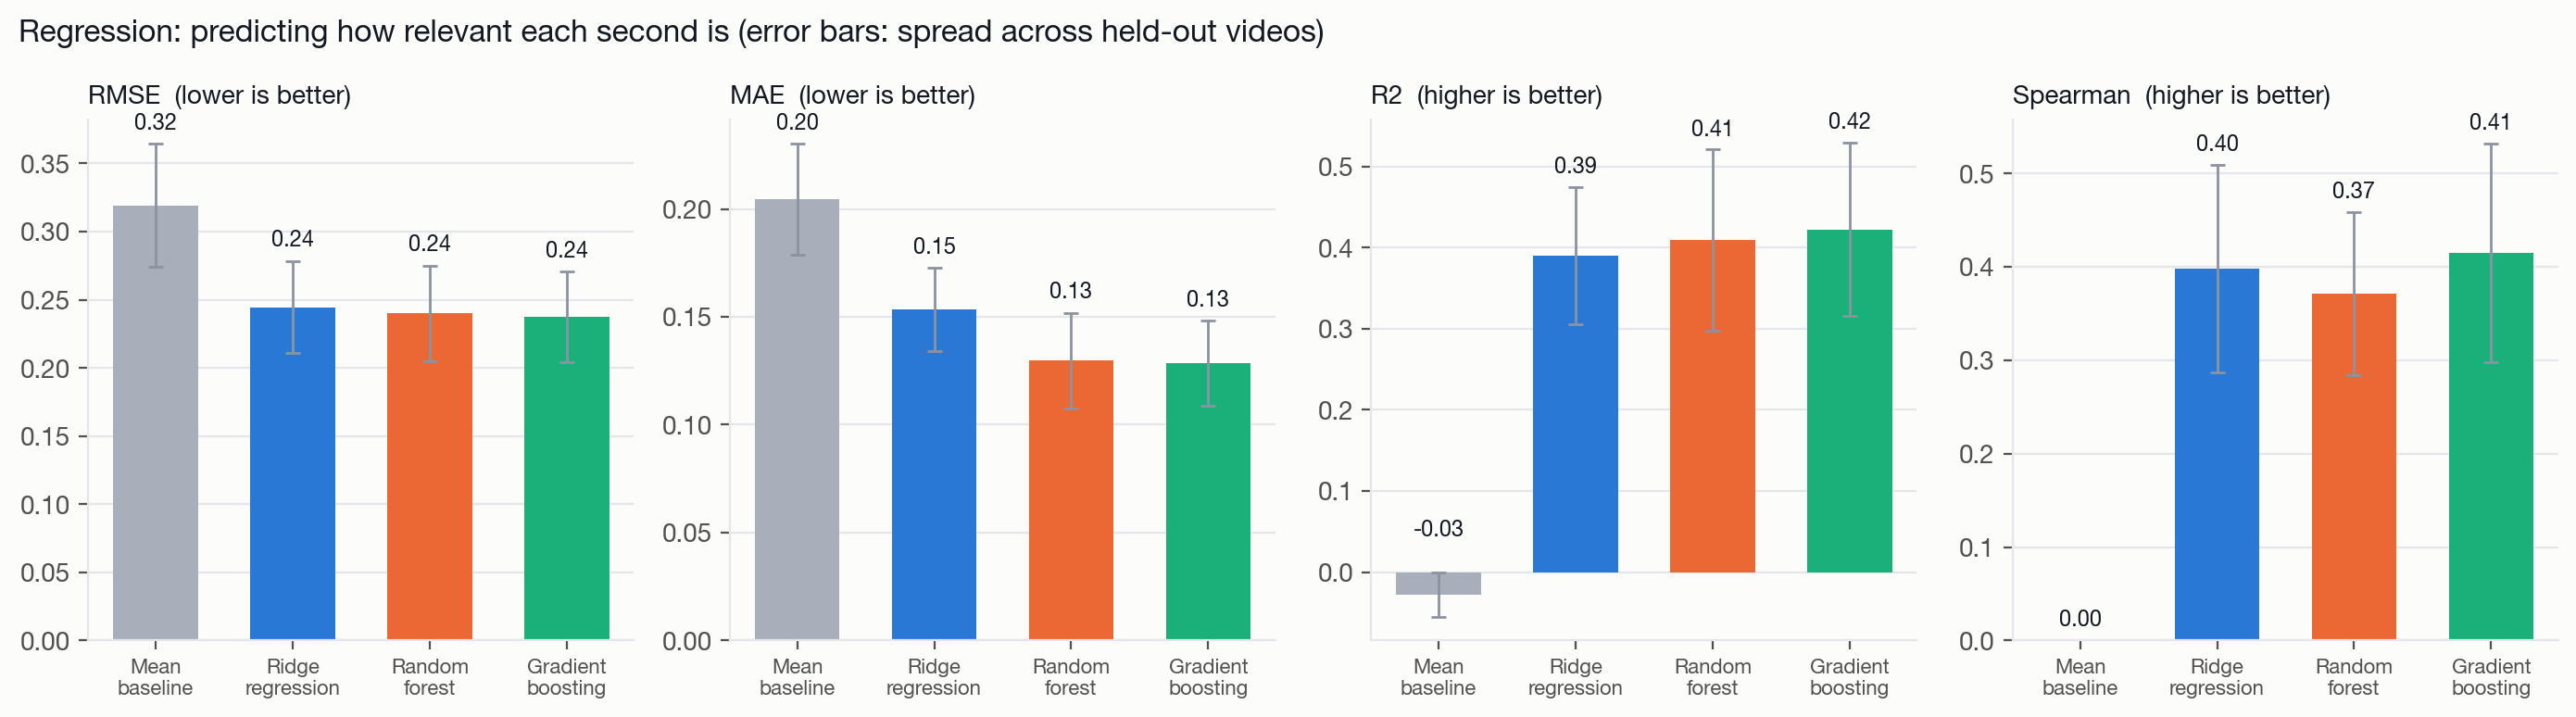

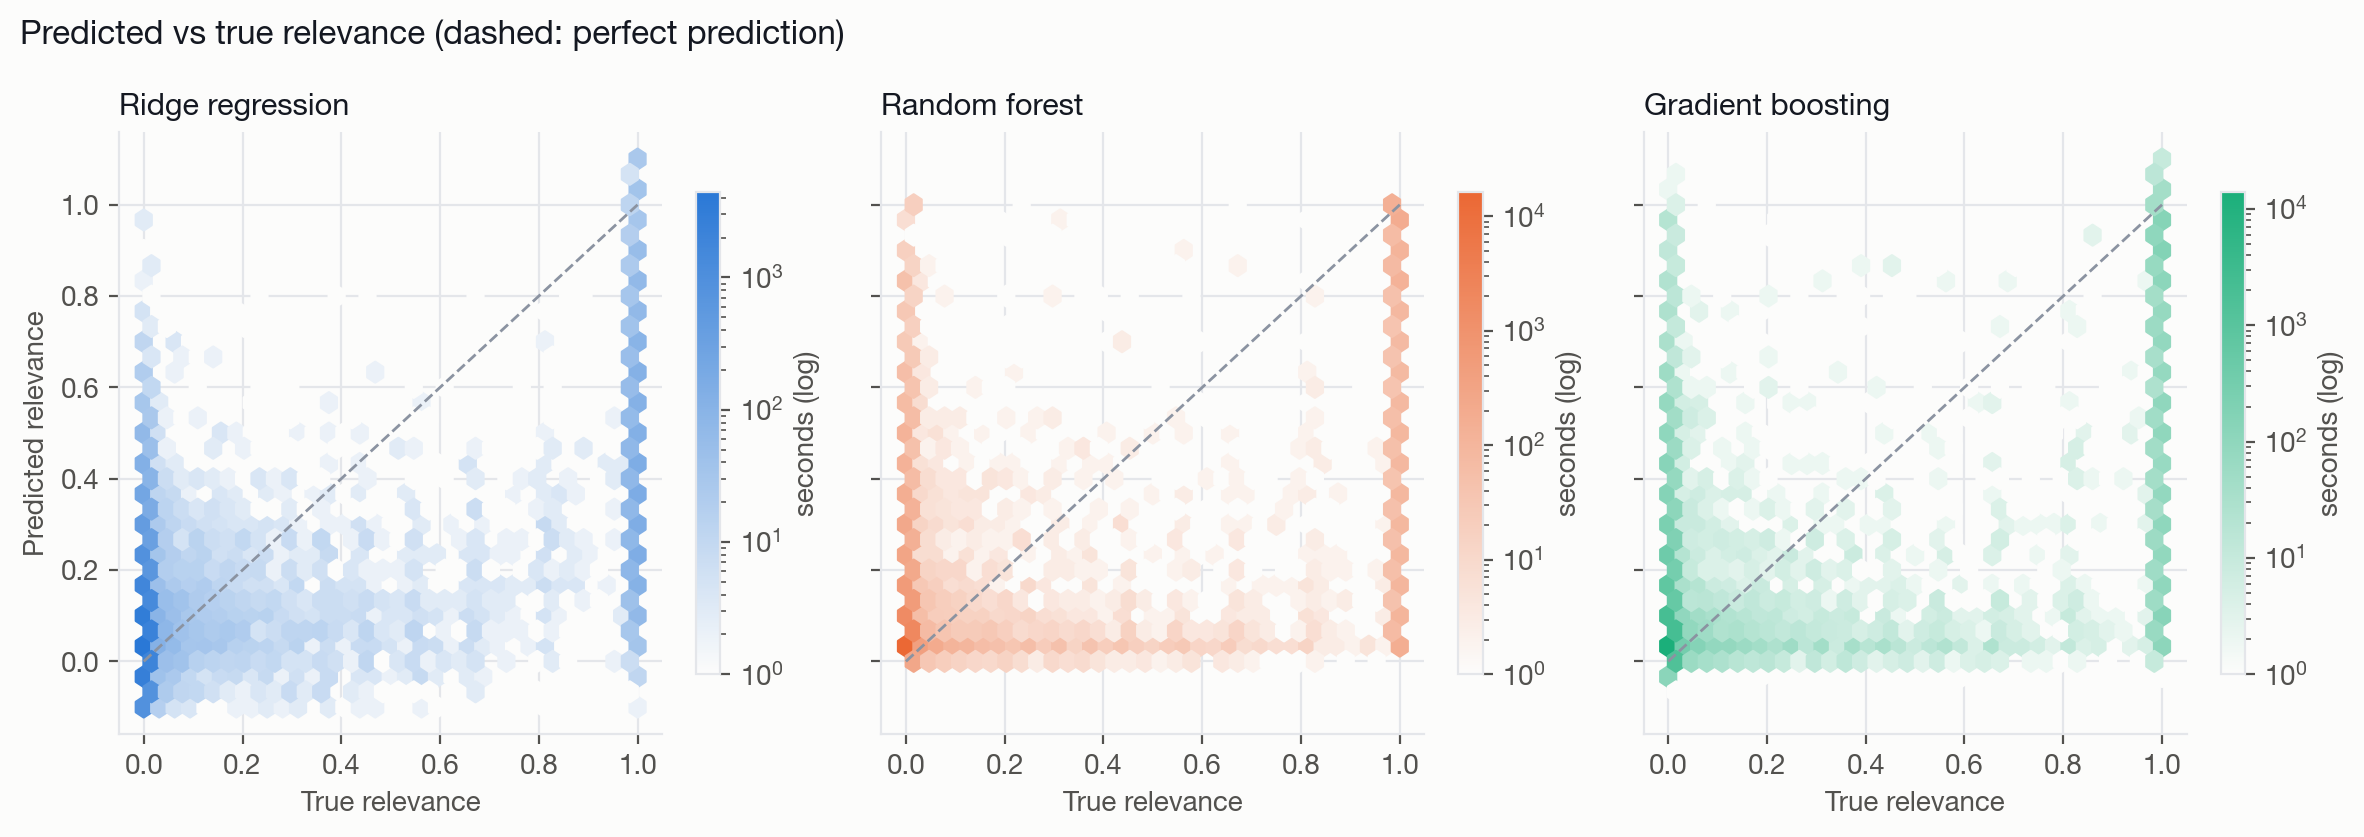

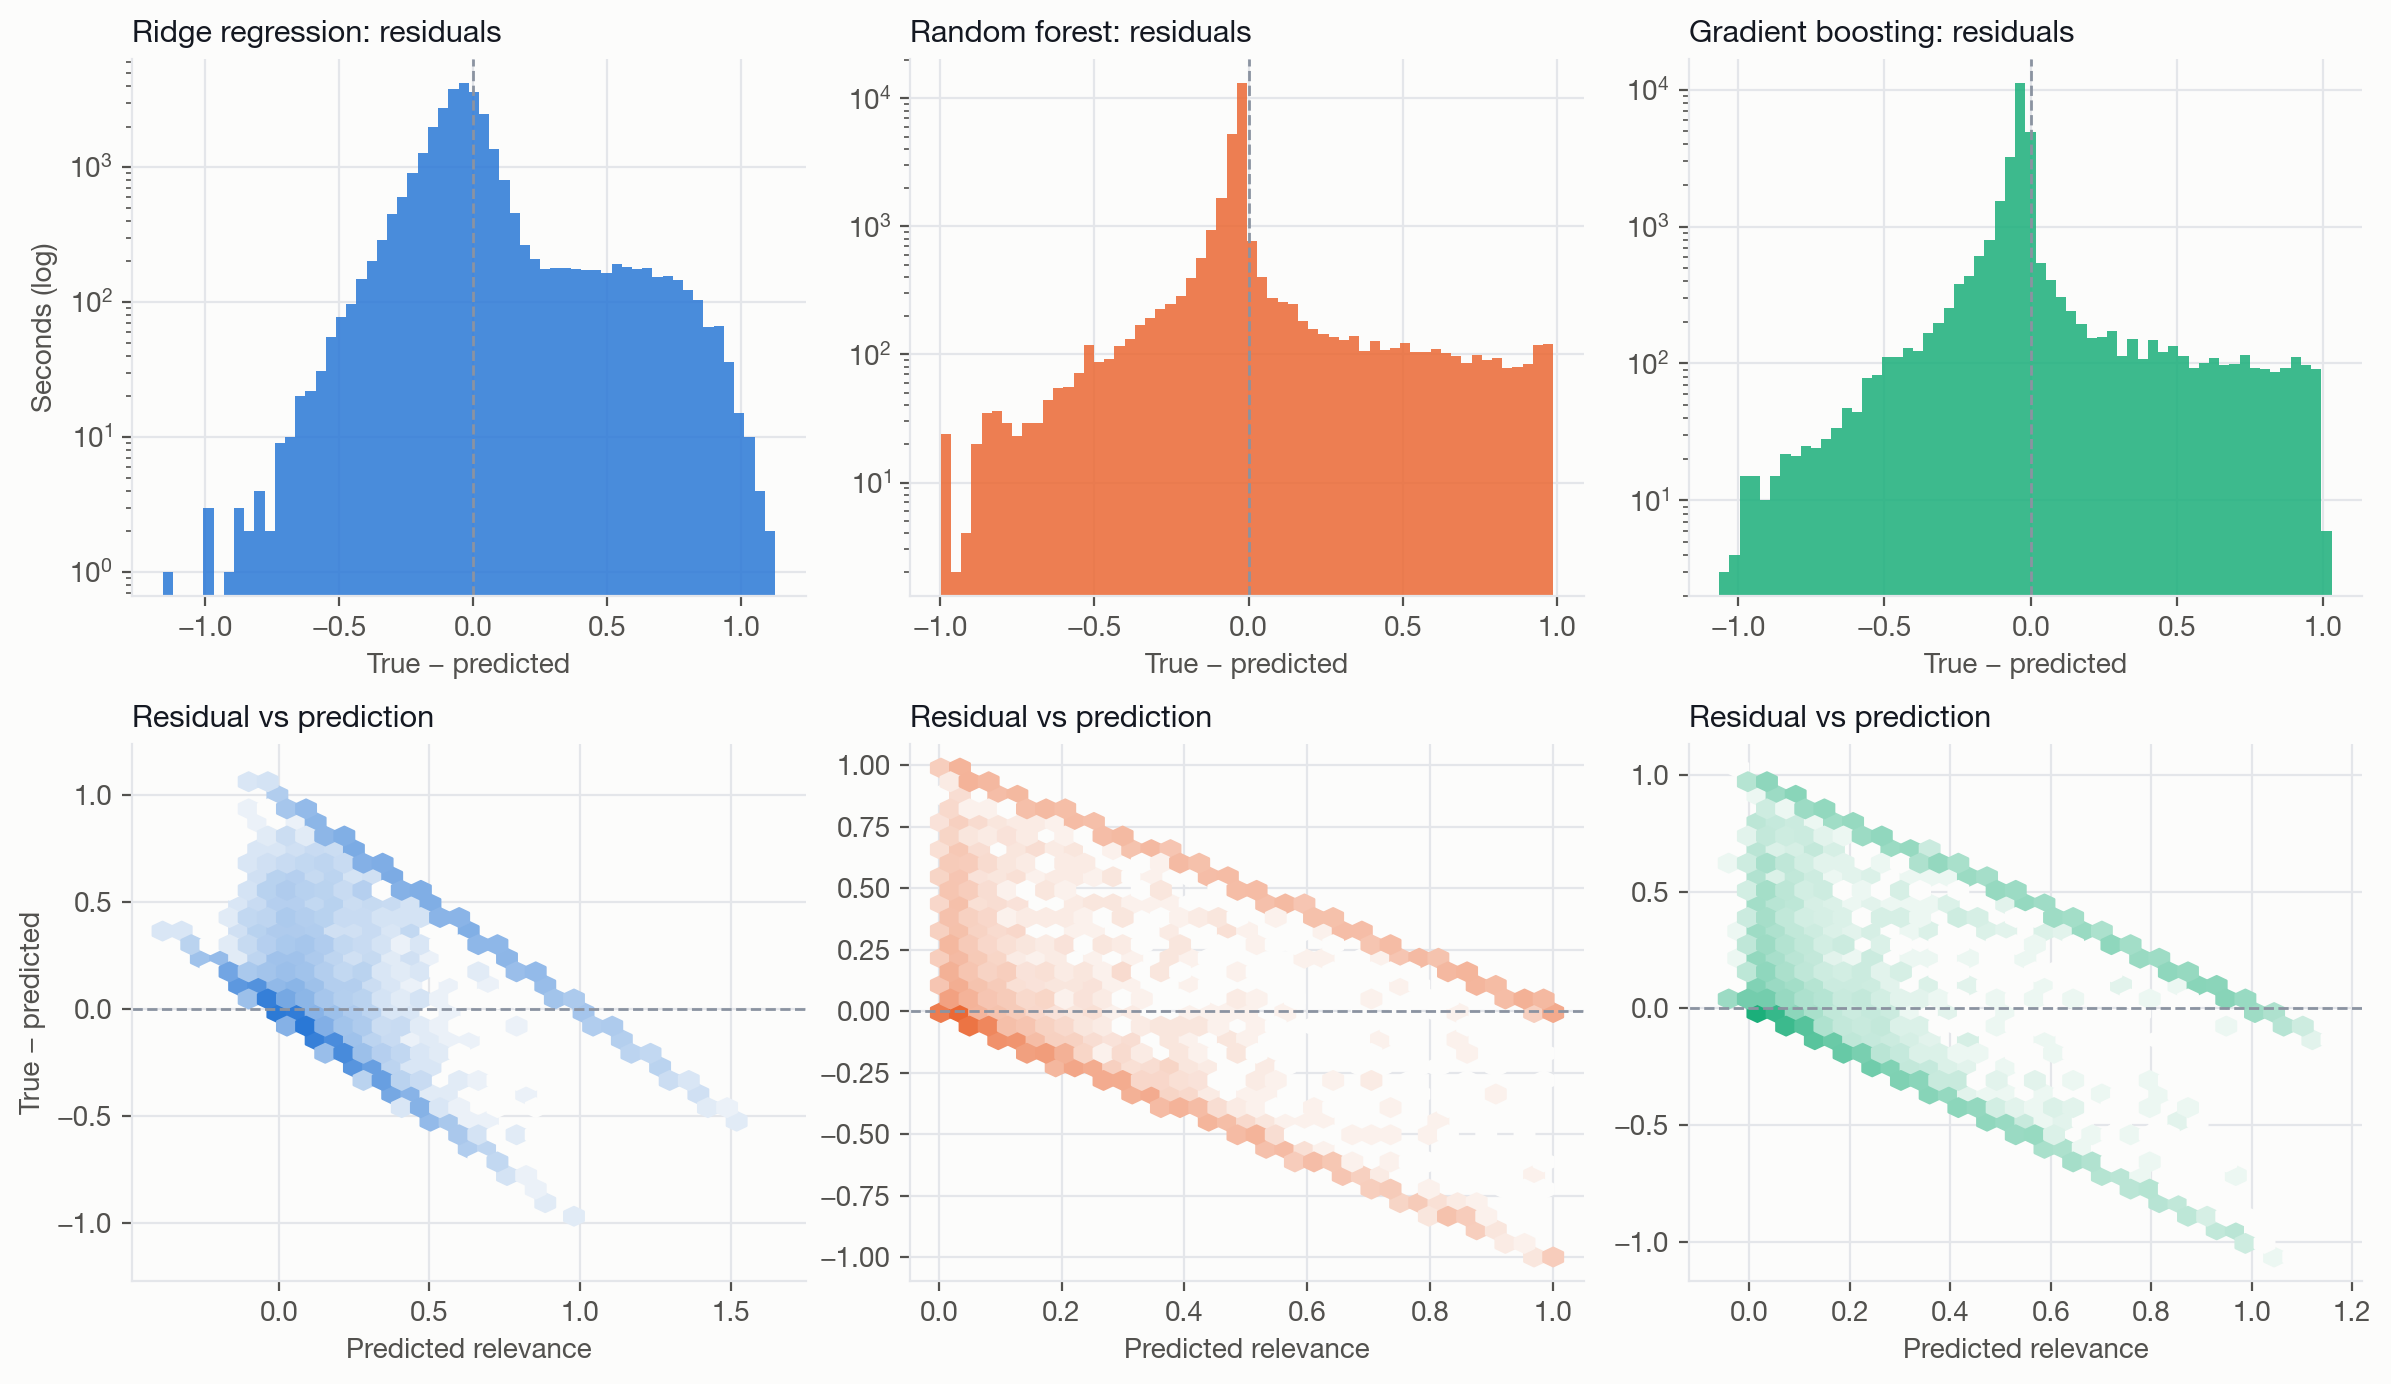

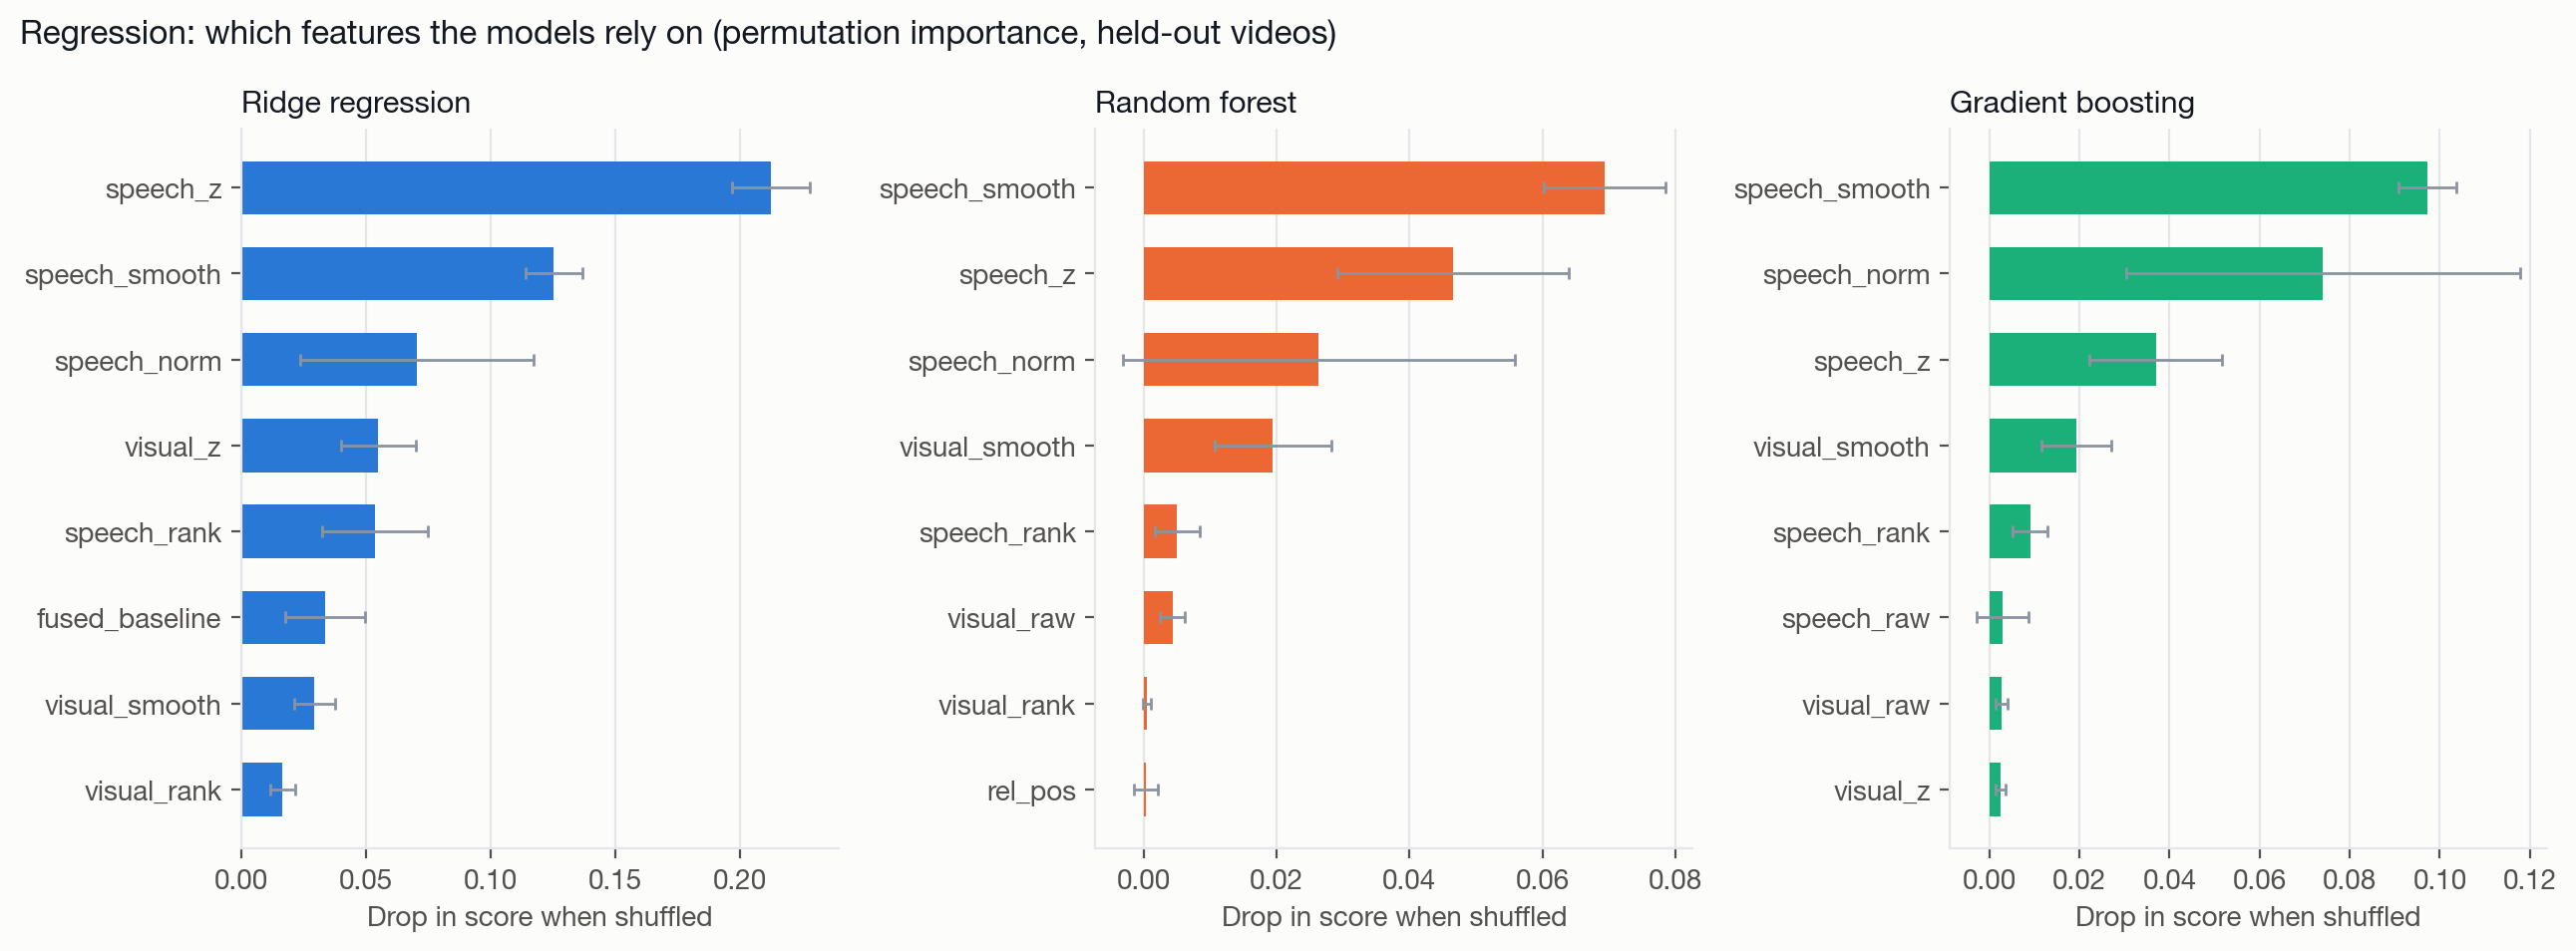

In [5]:
show("05_reg_metrics.png", 1000); show("06_reg_pred_vs_actual.png", 1000); show("07_reg_residuals.png", 950); show("08_reg_importance.png", 1000)

**Reading.** All three models beat the mean baseline by a wide margin (R² about 0.4 vs 0). They are within one standard deviation of each other across videos, so no regressor is clearly best. A plain linear model is nearly as good as the ensembles, which says the signal is in the features, not in model complexity. Predictions sit low for the many "0 or 1" labels: the models are conservative, shrinking toward the mean at the boundaries of true moments.

## 4. Classification

In [6]:
cls = pd.read_csv(T / "classification_summary.csv")
cls[["model", "precision_mean", "recall_mean", "f1_mean", "balanced_accuracy_mean", "roc_auc_mean", "pr_auc_mean"]].round(3)

,model,precision_mean,recall_mean,f1_mean,balanced_accuracy_mean,roc_auc_mean,pr_auc_mean
0,dummy,0.000,0.000,0.000,0.500,0.500,0.103
1,gradient_boosting,0.681,0.625,0.640,0.796,0.932,0.723
2,knn,0.649,0.600,0.616,0.781,0.916,0.687
3,logistic,0.715,0.612,0.651,0.792,0.941,0.746


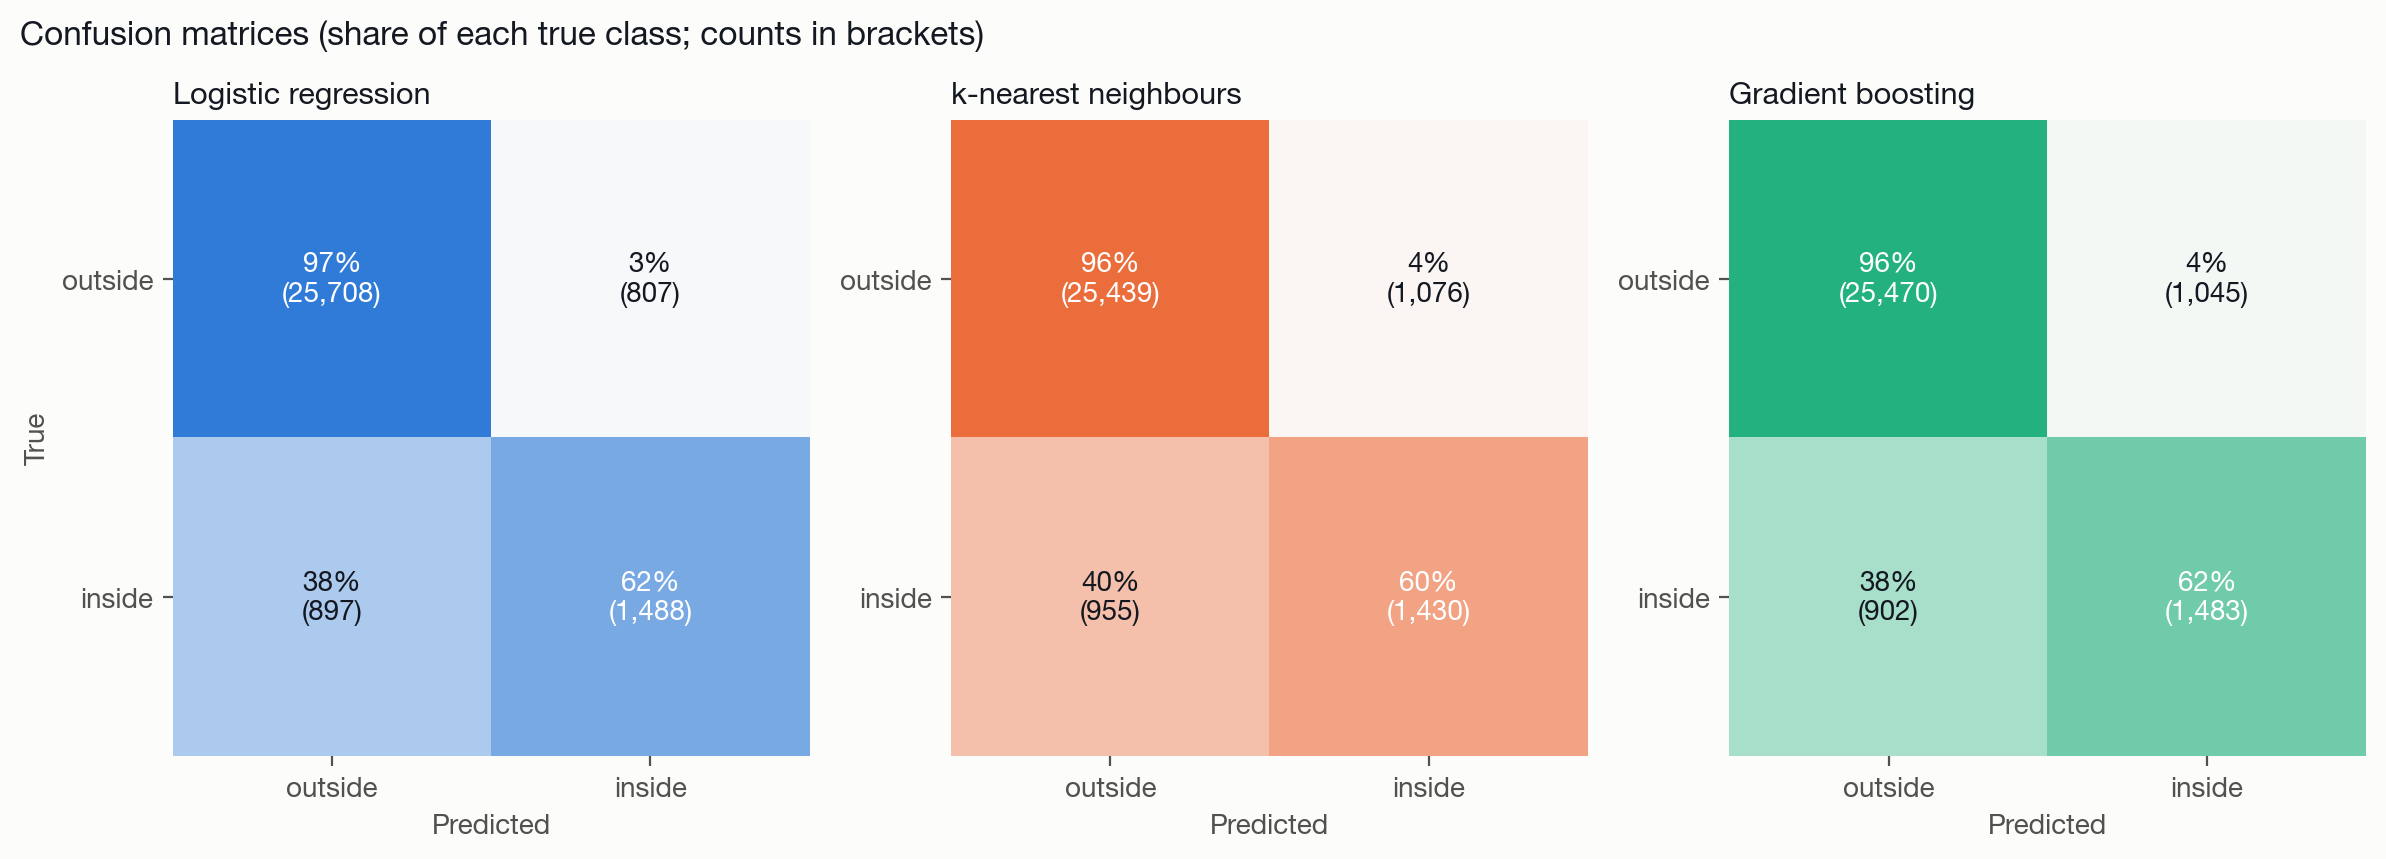

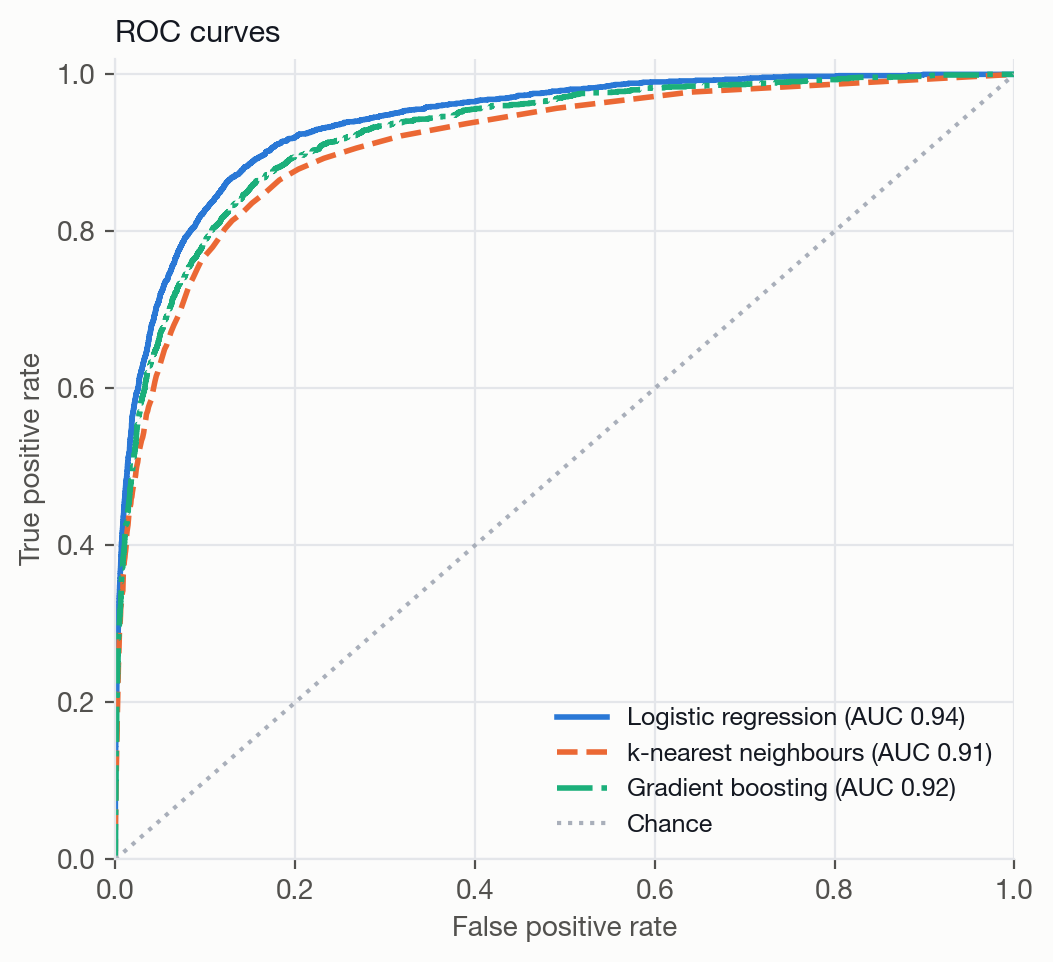

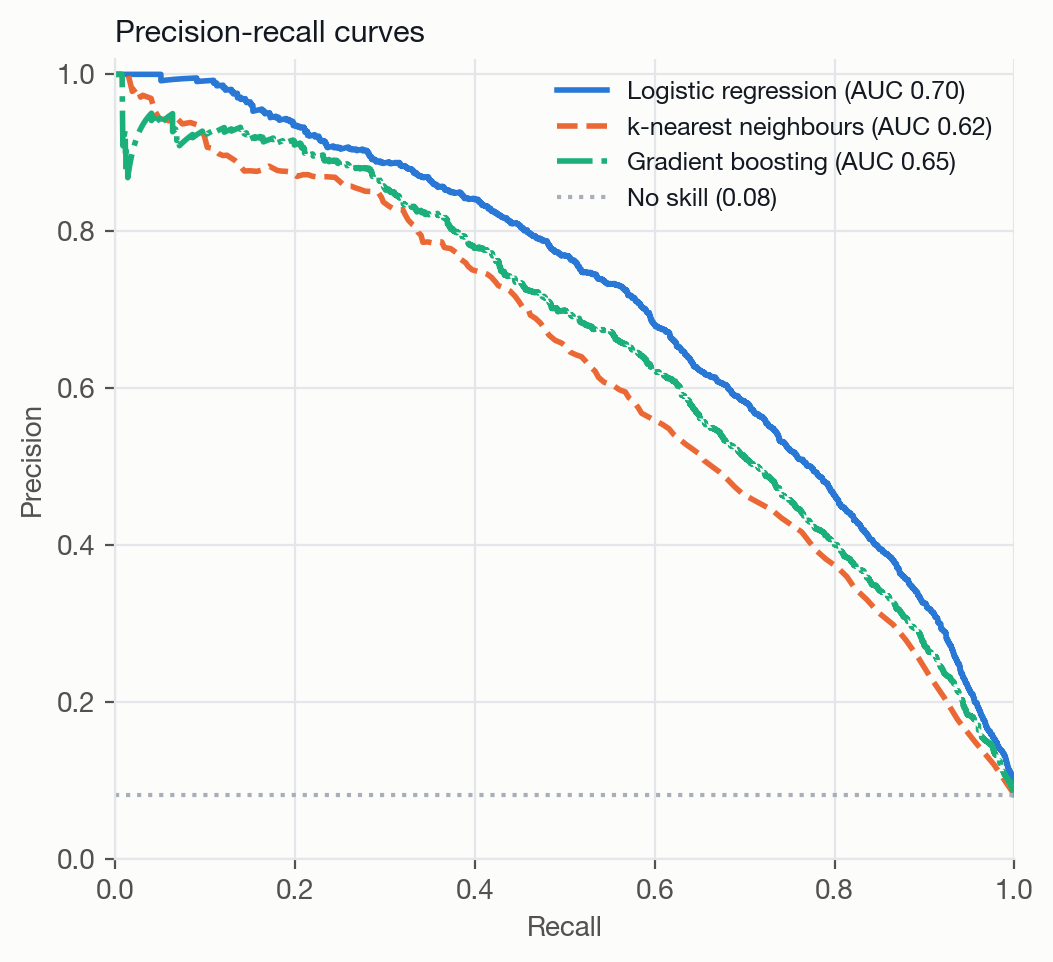

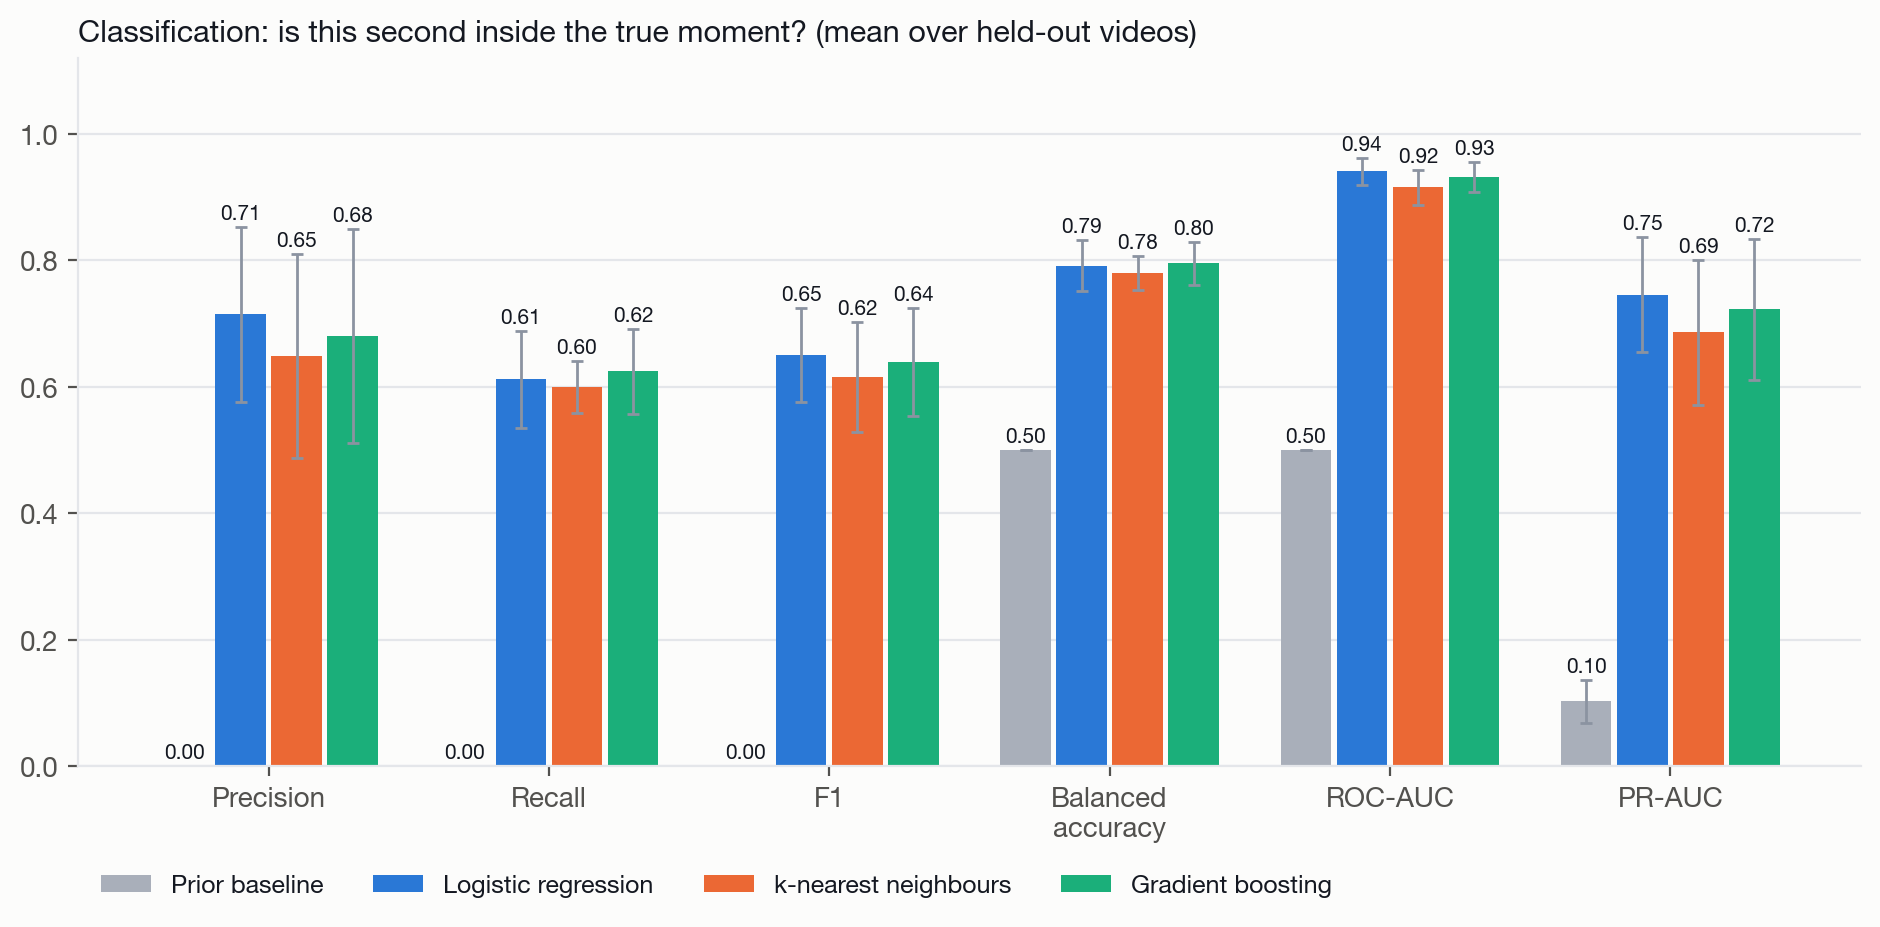

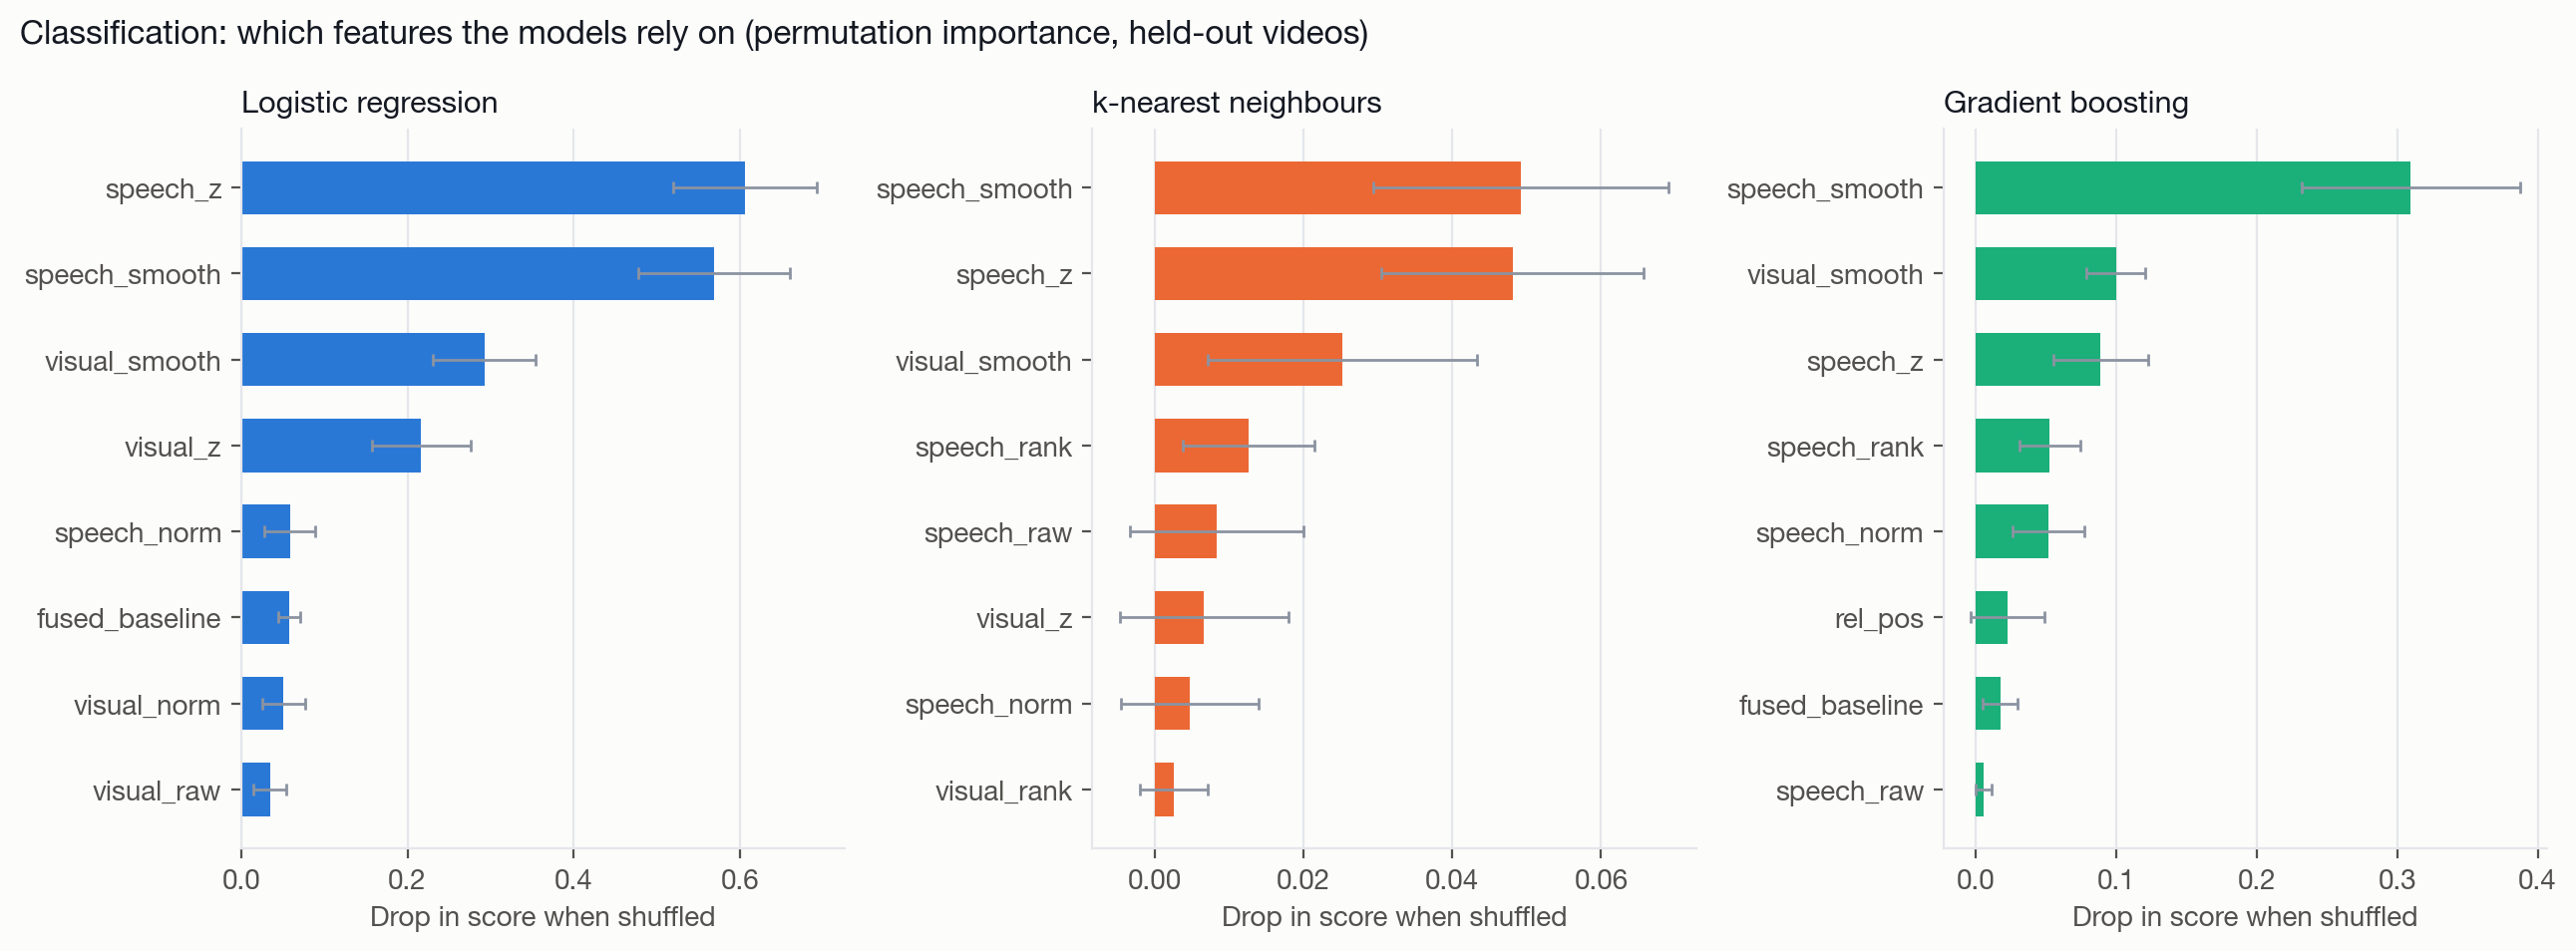

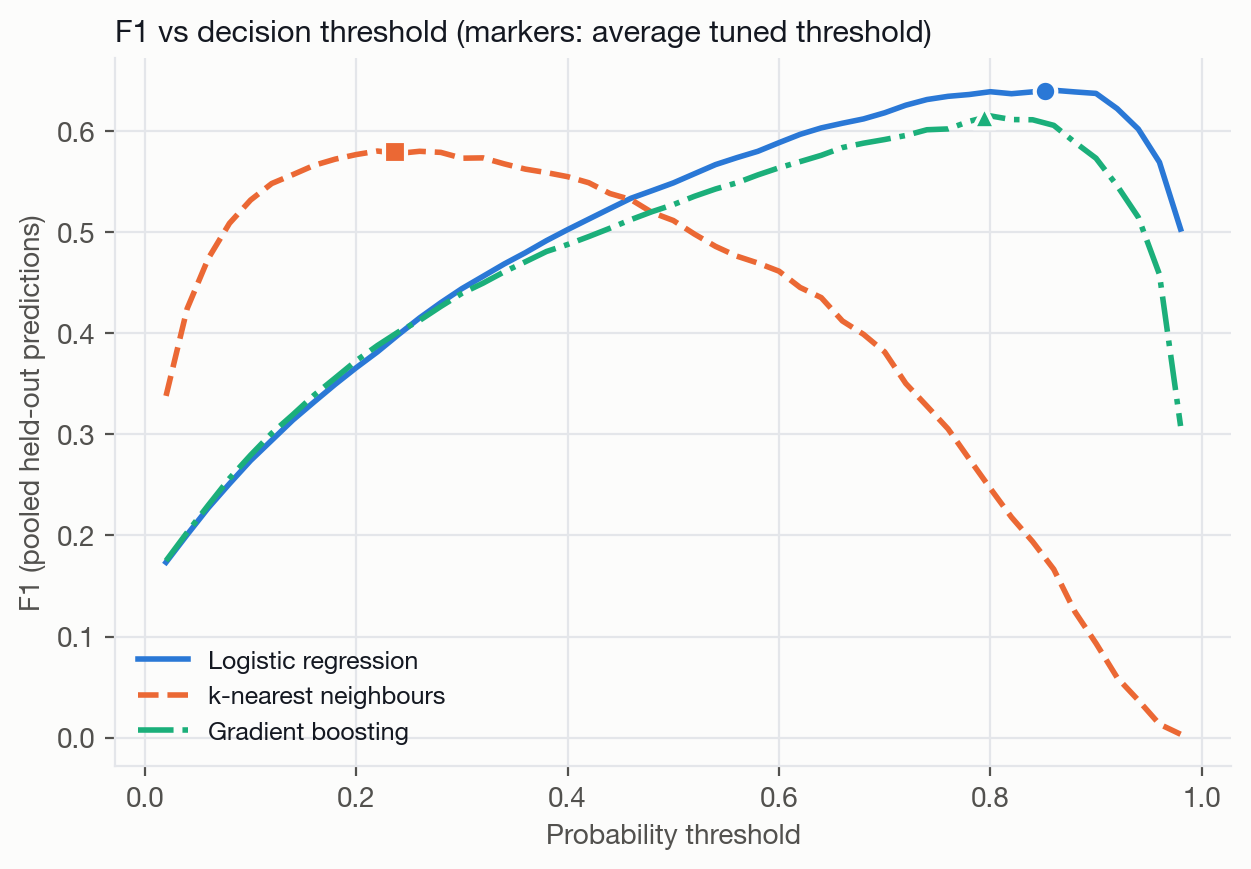

In [7]:
show("10_cls_confusion.png", 1000); show("11_cls_roc.png", 520); show("12_cls_pr.png", 520); show("13_cls_metrics.png", 1000); show("14_cls_importance.png", 1000); show("15_cls_threshold_f1.png", 650)

**Reading.** All three classifiers are far above the prior baseline (PR-AUC about 0.70 vs 0.10; ROC-AUC about 0.93). Logistic regression is marginally best on F1 and PR-AUC, again within noise of gradient boosting. About 60% of true seconds are found (recall) with roughly two thirds precision. The tuned threshold matters: F1 changes visibly with it. Permutation importance shows the models rely mostly on **smoothed** scores and **within-video z-scores** of speech and picture, not on raw similarity: temporal context and per-video calibration carry the signal.

## 5. Learning curves

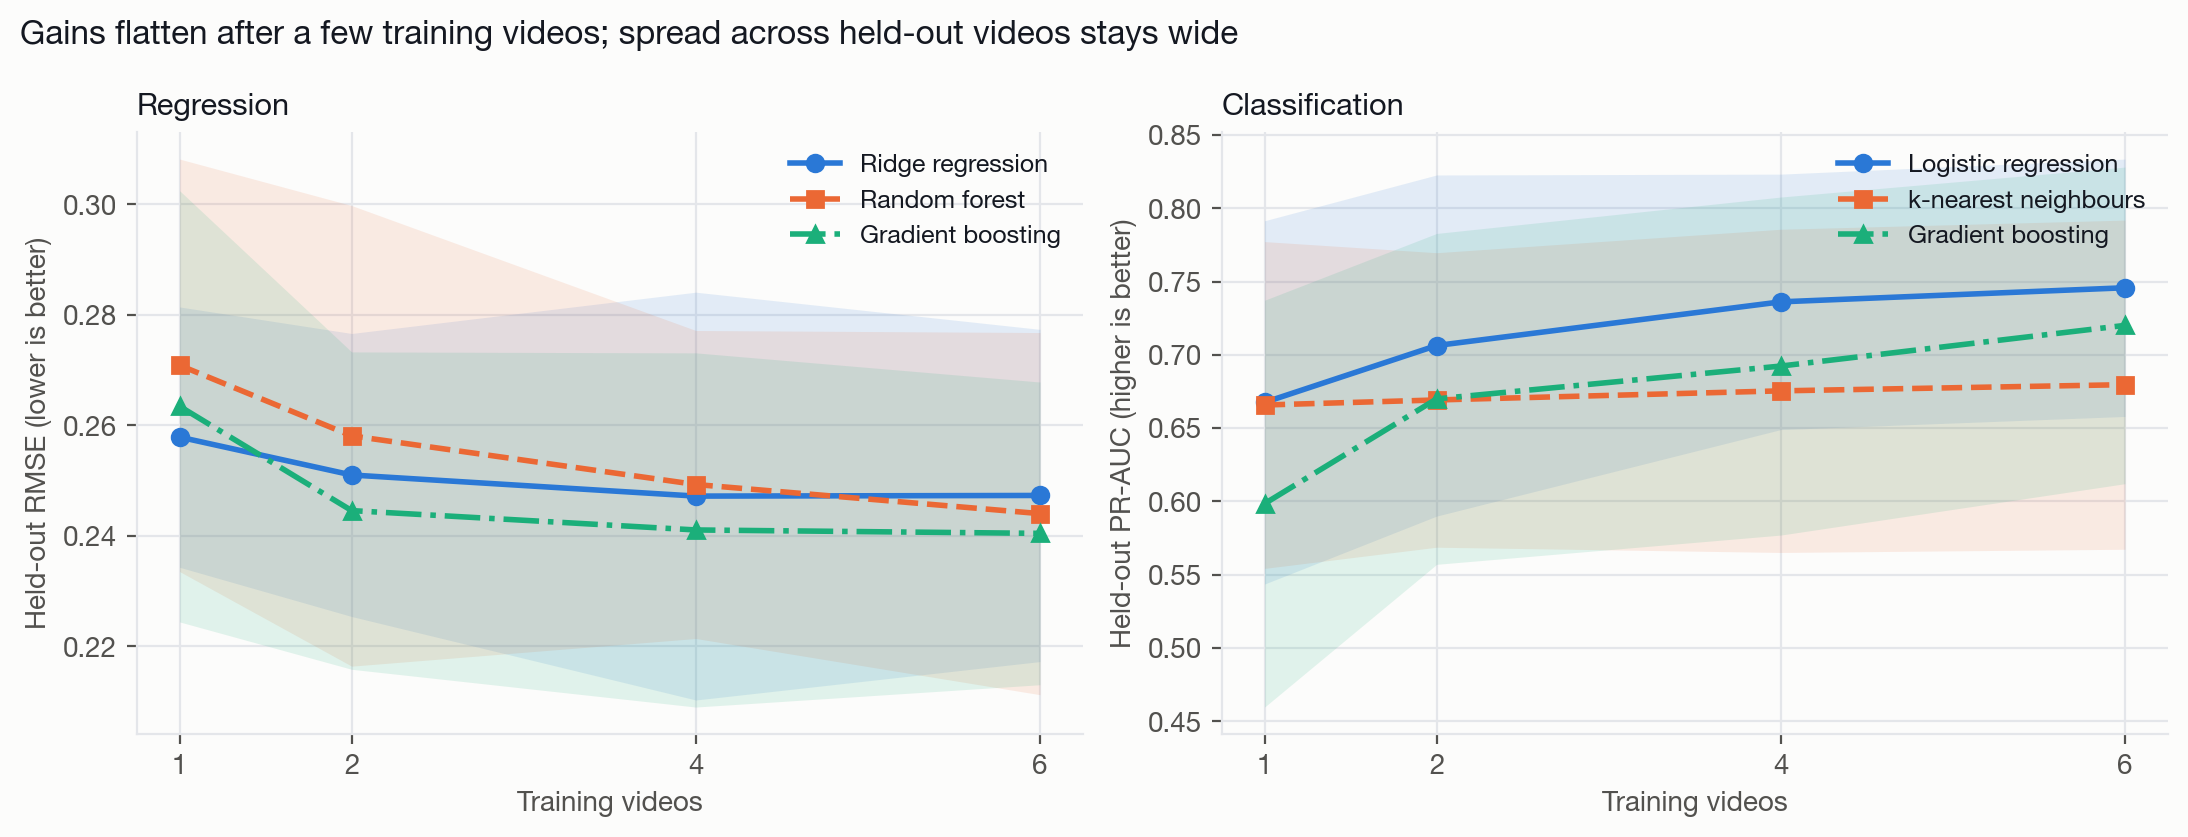

In [8]:
show("09_learning_curves.png", 1000)

Regression error stops improving after about two training videos. Classification PR-AUC rises slowly (logistic regression from 0.67 to 0.75 over six videos). The shaded spread across held-out videos is wide throughout, so differences between models are small relative to video-to-video variation.

## 6. Does it improve search?

Rank every second of a held-out query's video and check whether the true moment is on top. **Hit@k**: a true second is in the top k. **MRR**: 1 / rank of the first true second. Whiskers are 95% bootstrap intervals over the 86 queries.

In [9]:
r = pd.read_csv(T / "retrieval.csv")
r[["method", "hit_at_1", "hit_at_1_lo", "hit_at_1_hi", "hit_at_5", "mrr", "n_queries"]].round(3)

,method,hit_at_1,hit_at_1_lo,hit_at_1_hi,hit_at_5,mrr,n_queries
0,Fixed-weight fusion,0.872,0.802,0.942,0.965,0.913,86.0
1,Picture only,0.605,0.500,0.709,0.849,0.712,86.0
2,Speech only,0.895,0.826,0.953,0.919,0.913,86.0
3,Regression: Ridge regression,0.907,0.837,0.965,0.953,0.927,86.0
4,Regression: Random forest,0.872,0.791,0.942,0.942,0.904,86.0
5,Regression: Gradient boosting,0.907,0.837,0.965,0.965,0.931,86.0
6,Classification: Logistic regression,0.907,0.837,0.965,0.965,0.928,86.0
7,Classification: k-nearest neighbours,0.907,0.849,0.965,0.953,0.924,86.0
8,Classification: Gradient boosting,0.860,0.779,0.930,0.942,0.892,86.0
9,Random,0.082,0.066,0.098,0.372,0.231,86.0


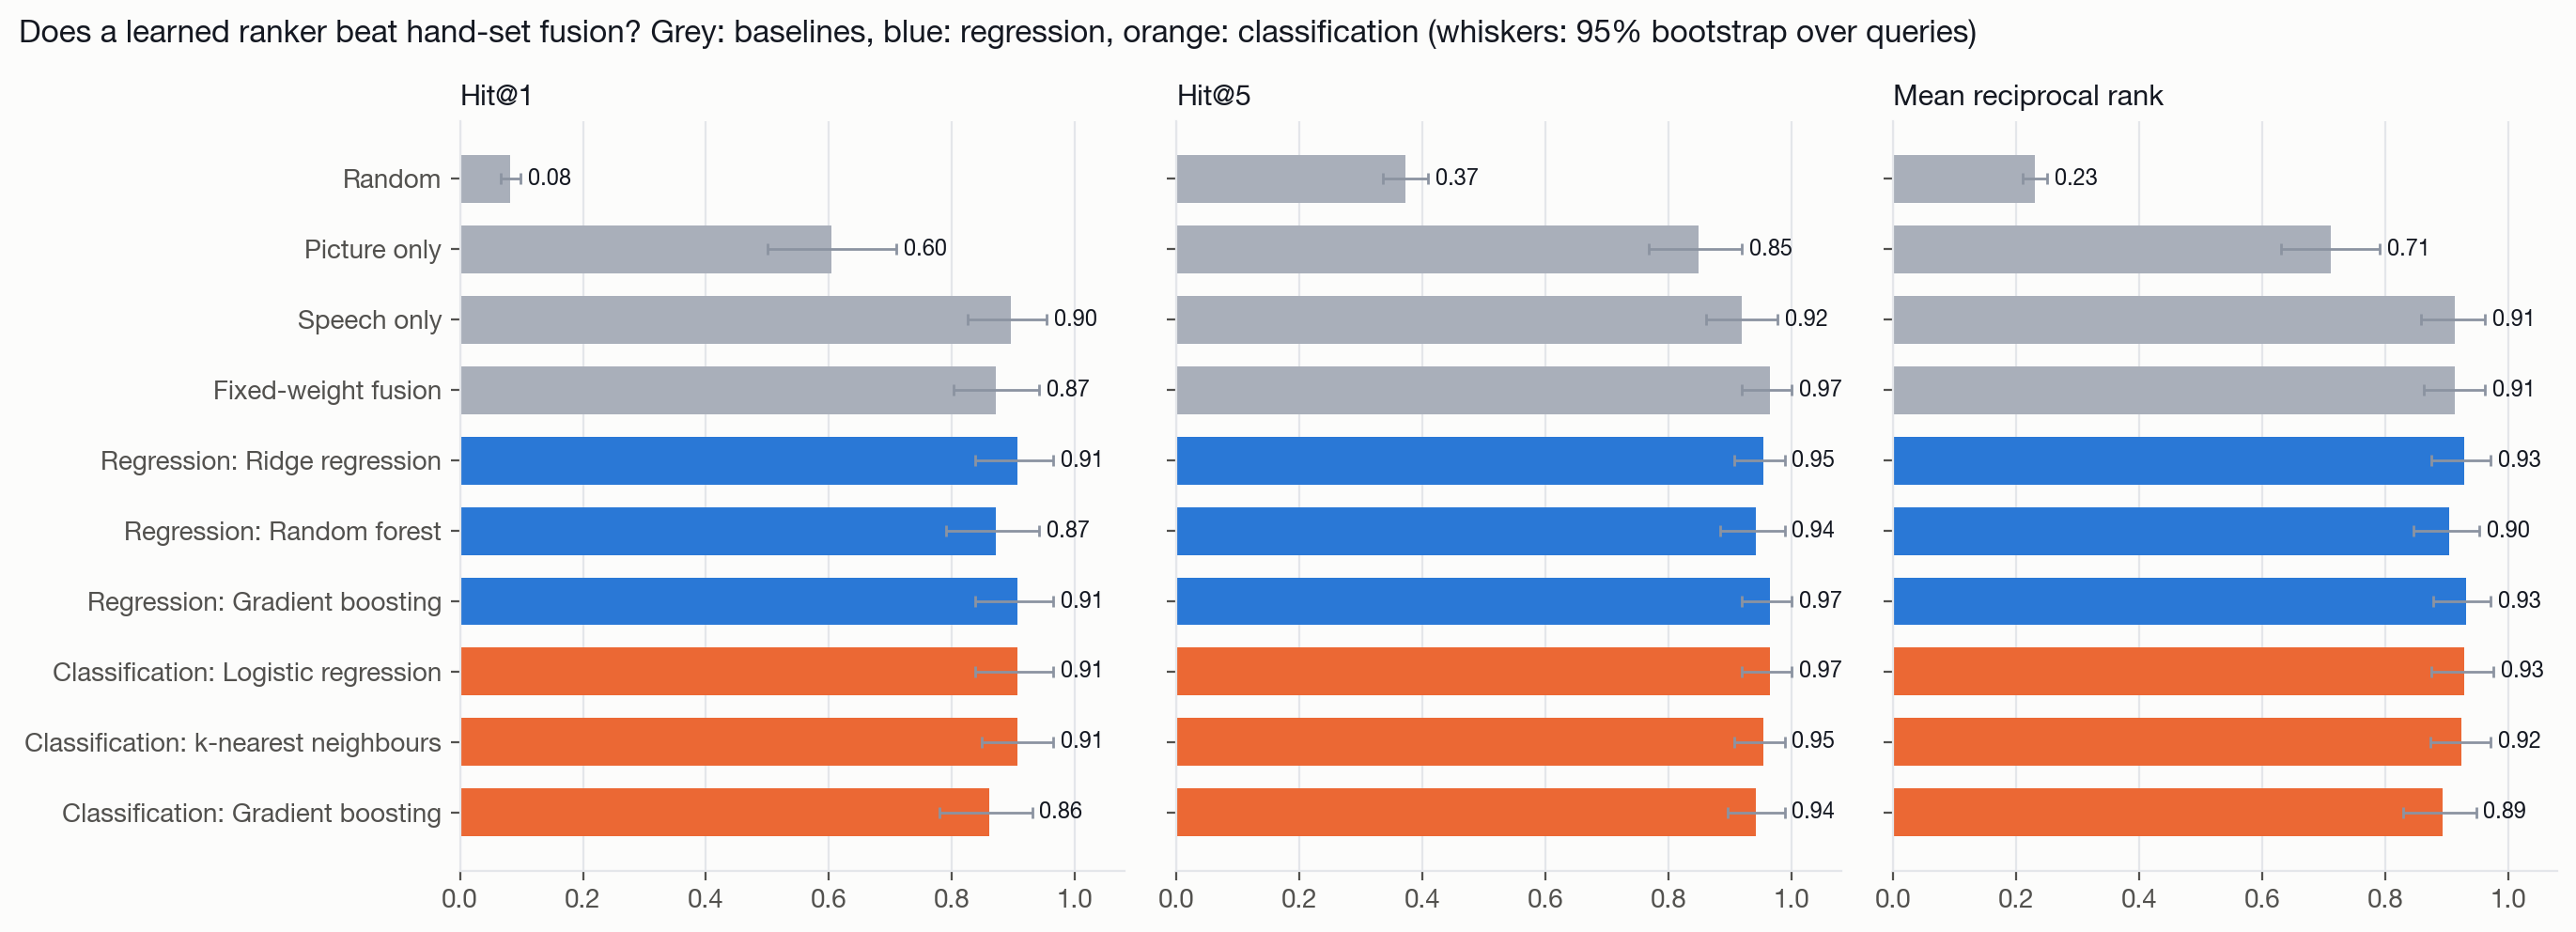

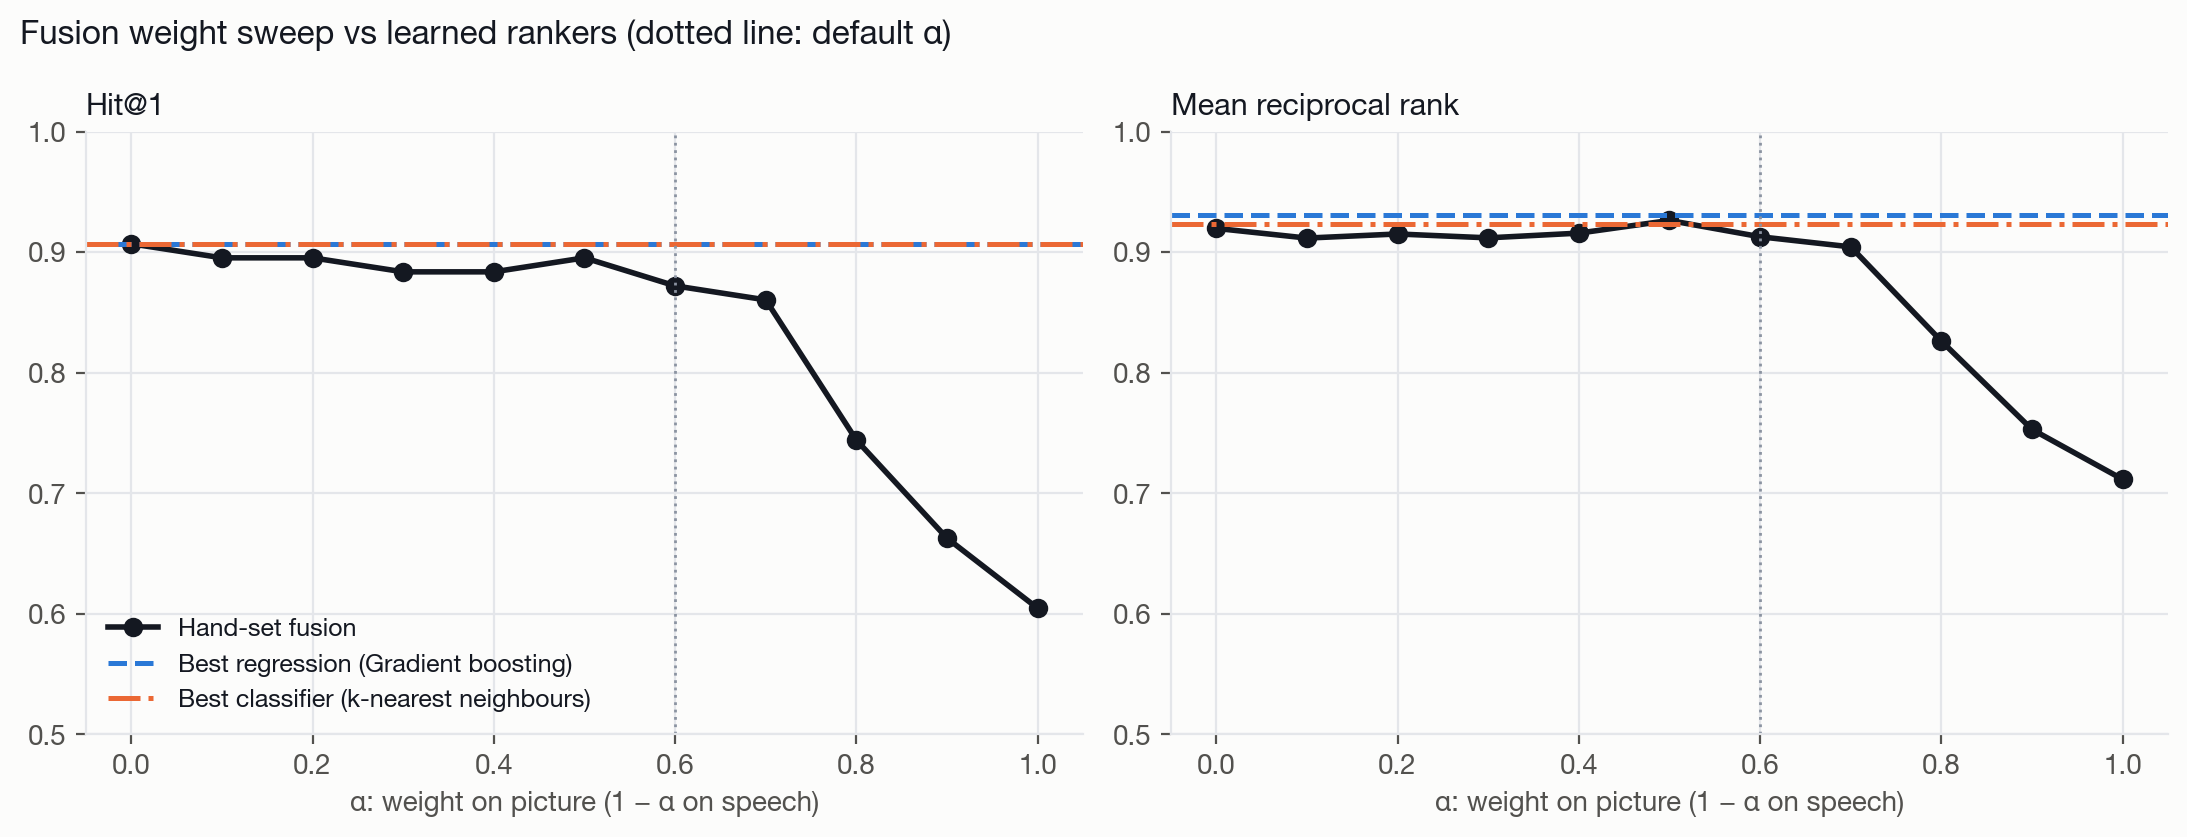

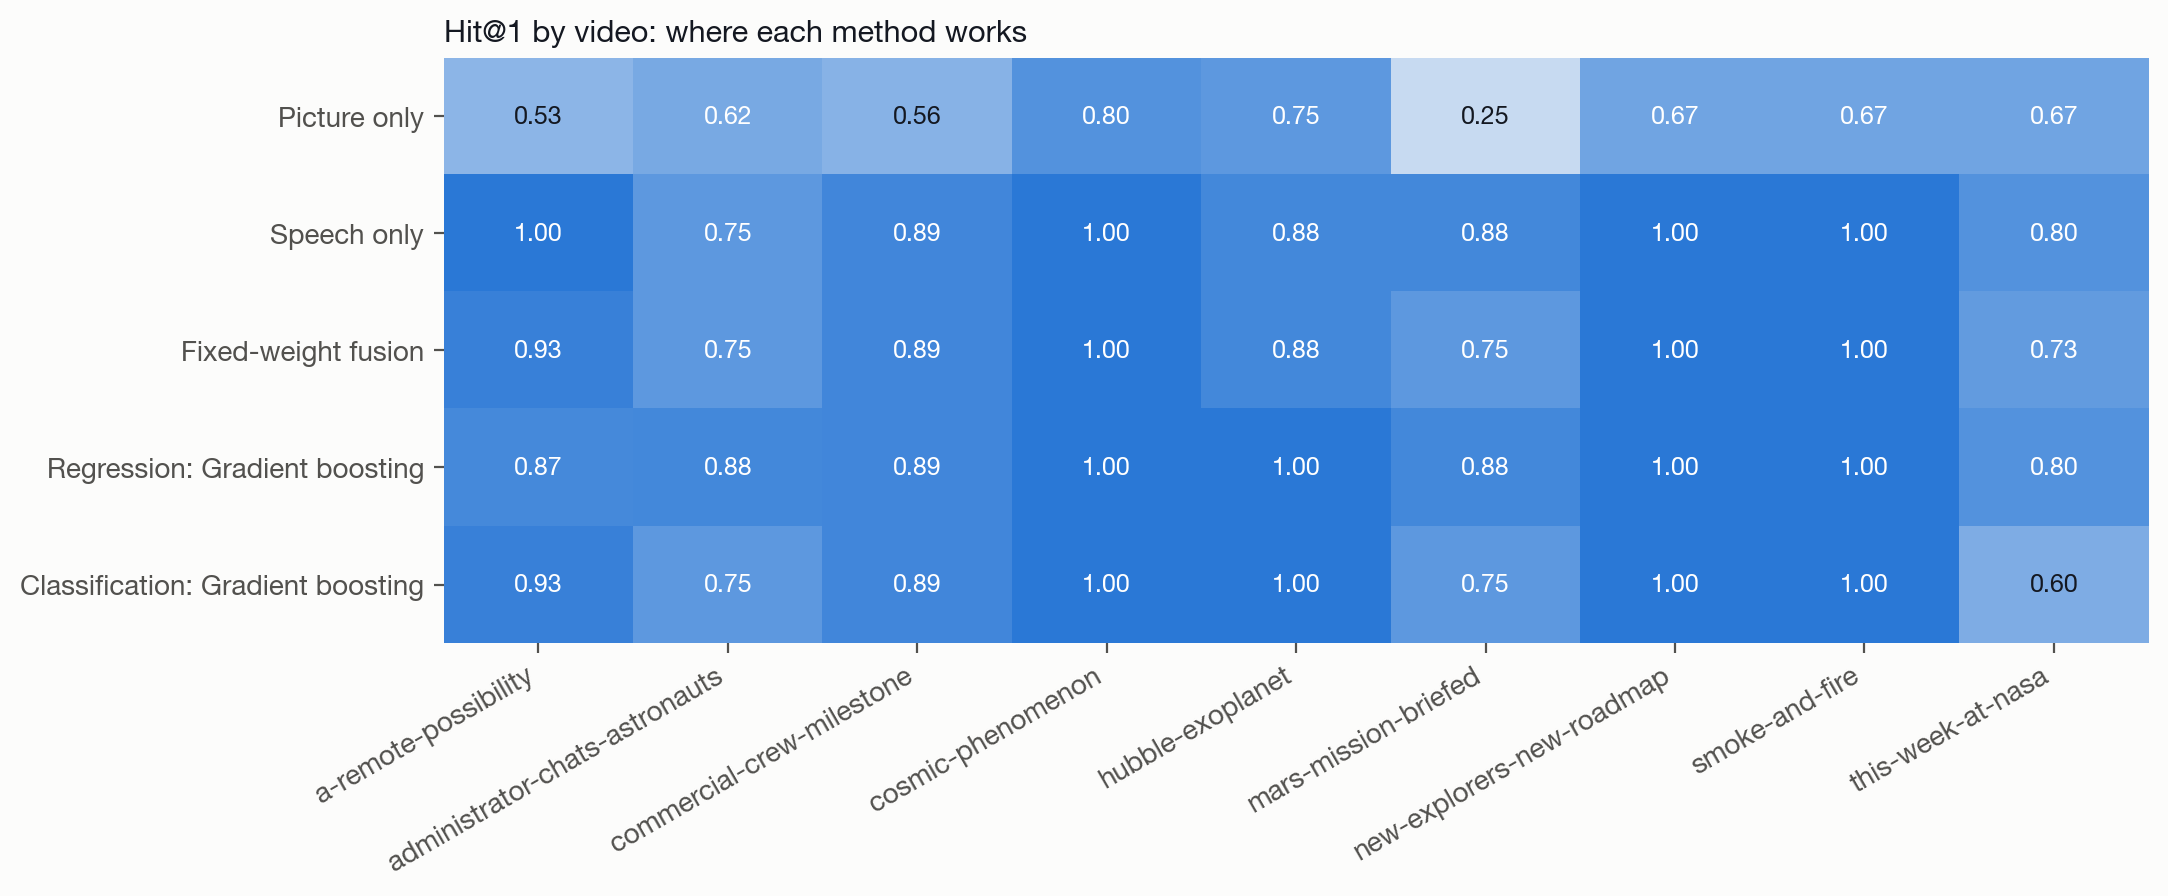

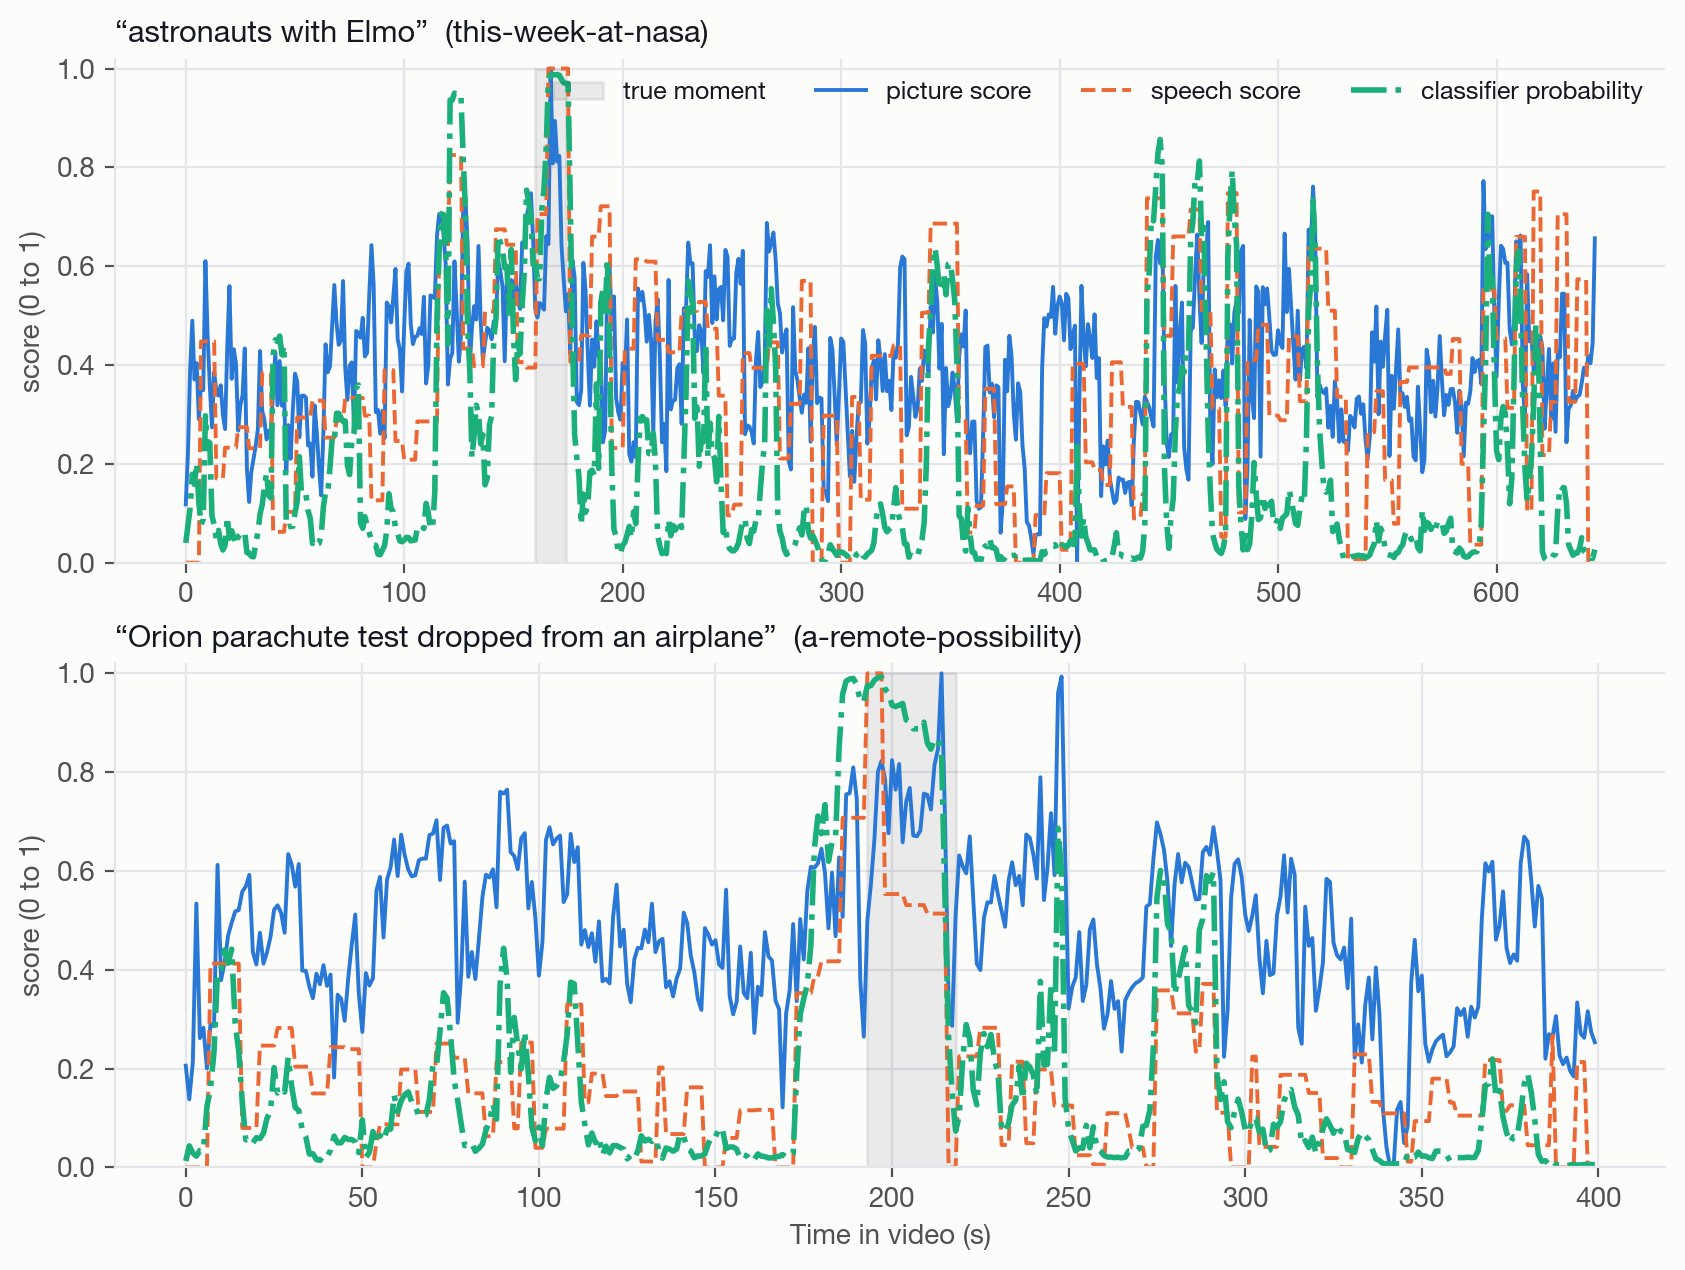

In [10]:
show("16_retrieval_comparison.png", 1100); show("17_alpha_sweep.png", 1000); show("18_per_video_hit1.png", 1000); show("04_example_traces.png", 950)

**Reading.**

* Learned rankers reach Hit@1 of about 0.87 to 0.91, versus 0.87 for the hand-set fusion. The intervals overlap heavily, so **the learned models do not clearly beat hand-set fusion** on this benchmark.
* Picture-only (0.60) is far worse than speech-only (about 0.90) or any fusion. That is partly a labelling effect: intervals were written from transcripts. The α sweep shows fusion is flat for α ≤ 0.7 and degrades as picture dominates.
* The supervised models are most useful as *evidence*: they confirm the engineered features carry real signal (R² 0.4, PR-AUC 0.7), and a linear model recovers most of it.

## 7. Limits

* 86 queries over 9 videos is small; every metric has wide intervals.
* Labels derive from transcripts, favouring the speech signal; a picture-labelled benchmark would likely favour picture and fusion.
* One content domain (NASA news). Results may not transfer to lectures, sports or silent footage.
* Positives are about 8% of seconds, so accuracy is not reported as a headline metric.